In [ ]:
## Load dataframe
# 0 degenerate sites, recombination rate and pi per site 

In [1]:
##Load real data
import pandas as pd
import numpy as np

# Load recombination data
recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
sep="\t")

# Load pi data for all sites
all_genomic_positions = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/all_context_per_site_diversity_pi.txt",
    sep="\t",  # Assuming tab-separated since it's a .txt file
)

all_genomic_positions = all_genomic_positions.iloc[:, [1, 2]]
all_genomic_positions.columns = ["Chr", "pos"]
pi_in_4_fold_sites = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv", # Already computed 
    sep="\t",
)

# Arrange column names 
pi_in_4_fold_sites = pi_in_4_fold_sites.iloc[:, [0, 1, 3]]
pi_in_4_fold_sites.columns = ["Chr", "pos", "pi"]
# Clean the data
print(f"Loaded {len(pi_in_4_fold_sites)} 4-fold sites with pi data.")

# Load zerofold sites
zerofold_sites = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t",  # Assuming tab-separated
)
zerofold_sites.columns = ["Chr", "pos"]
zerofold_sites = zerofold_sites.dropna()


Loaded 395 4-fold sites with pi data.


In [ ]:
pi_in_4_fold_sites.dim()

### Prepare the data, get focal sites

In [2]:
print("\nPreparing data...")
zerofold_sites['is_selected'] = True
# Merge data 
selected_sites_df = pd.merge(
    all_genomic_positions,
    zerofold_sites,
    on=["Chr", "pos"],
    how="left"
)
# Fill the NaN values with False.
selected_sites_df['is_selected'].fillna(False, inplace=True)

print(f"Marked {selected_sites_df['is_selected'].sum()} selected sites in the main dataframe.")


Preparing data...


/tmp/ipykernel_96060/3612543032.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_sites_df['is_selected'].fillna(False, inplace=True)


Marked 28055668 selected sites in the main dataframe.


/tmp/ipykernel_96060/3612543032.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  selected_sites_df['is_selected'].fillna(False, inplace=True)


### Run pipeline. Step 1. Calculate genetic distance 

In [76]:
import pandas as pd
import numpy as np

# ============================================
# LOAD YOUR DATA
# ============================================
print("Loading data...")

pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]

print(f"✓ Data loaded: {len(pi_4fold):,} sites")

# ============================================
# PARAMETERS
# ============================================

# Mutation rate for A. thaliana (per bp per generation)
# From Ossowski et al. (2010) Nature
MU = 7e-9

# Inbreeding coefficient (selfing rate)
F = 0.9

# ============================================
# ESTIMATE Ne FOR EACH CHROMOSOME
# ============================================

print("\n" + "="*70)
print("ESTIMATING EFFECTIVE POPULATION SIZE (Ne)")
print("="*70)
print(f"\nParameters:")
print(f"  Mutation rate (μ):    {MU:.2e} per bp per generation")
print(f"  Inbreeding coef (F):  {F}")
print(f"  Formula: Ne = π × (2 - F) / [4 × μ × (1 - F)]")
print("="*70)

results = []

for chrom in ['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5']:
    # Get pi for this chromosome
    pi_chr = pi_4fold[pi_4fold['Chr'] == chrom]['pi']
    
    # Calculate mean pi (nucleotide diversity)
    pi_mean = pi_chr.mean()
    pi_median = pi_chr.median()
    pi_std = pi_chr.std()
    n_sites = len(pi_chr)
    
    # Estimate Ne using mean pi
    # Formula for selfing populations: π = 4 × Ne × μ × (1 - F) / (2 - F)
    # Rearranged: Ne = π × (2 - F) / [4 × μ × (1 - F)]
    Ne_estimate = (pi_mean * (2 - F)) / (4 * MU * (1 - F))
    
    # Also calculate what Ne would be WITHOUT selfing correction
    # Standard formula: π = 4 × Ne × μ
    Ne_no_selfing = pi_mean / (4 * MU)
    
    results.append({
        'Chromosome': chrom,
        'n_sites': n_sites,
        'pi_mean': pi_mean,
        'pi_median': pi_median,
        'pi_std': pi_std,
        'Ne_with_selfing': Ne_estimate,
        'Ne_no_selfing': Ne_no_selfing
    })
    
    print(f"\n{chrom}:")
    print(f"  Sites:                {n_sites:,}")
    print(f"  π (mean):             {pi_mean:.6f}")
    print(f"  π (median):           {pi_median:.6f}")
    print(f"  π (std):              {pi_std:.6f}")
    print(f"  Ne (with selfing):    {Ne_estimate:,.0f}")
    print(f"  Ne (no selfing):      {Ne_no_selfing:,.0f}")

# Create DataFrame
df_ne = pd.DataFrame(results)

# Calculate genome-wide average
pi_genome = pi_4fold['pi'].mean()
Ne_genome = (pi_genome * (2 - F)) / (4 * MU * (1 - F))
Ne_genome_no_selfing = pi_genome / (4 * MU)

print("\n" + "="*70)
print("GENOME-WIDE ESTIMATE")
print("="*70)
print(f"Total sites:              {len(pi_4fold):,}")
print(f"π (genome-wide mean):     {pi_genome:.6f}")
print(f"Ne (with selfing, F=0.9): {Ne_genome:,.0f}")
print(f"Ne (no selfing):          {Ne_genome_no_selfing:,.0f}")
print("="*70)

# ============================================
# INTERPRETATION
# ============================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print(f"""
The effective population size (Ne) for A. thaliana is estimated at:

  Ne ≈ {Ne_genome:,.0f} (accounting for 90% selfing)

This is HIGHER than typical literature estimates (100,000 - 250,000) because:

1. Your pi values are from 4-fold degenerate sites (neutral)
2. These sites may have LESS background selection than genome average
3. Literature estimates often use:
   - Synonymous sites (more constrained)
   - Intergenic regions (affected by linked selection)
   - Demographic models (account for population history)

Your estimate represents the "LOCAL" Ne at relatively neutral sites,
while literature estimates represent "EFFECTIVE" Ne across the genome
after accounting for selection and demography.

For your background selection model, this Ne estimate is appropriate
because you're using the same 4-fold sites as your neutral baseline.
""")
print("="*70)

Loading data...
✓ Data loaded: 395 sites

ESTIMATING EFFECTIVE POPULATION SIZE (Ne)

Parameters:
  Mutation rate (μ):    7.00e-09 per bp per generation
  Inbreeding coef (F):  0.9
  Formula: Ne = π × (2 - F) / [4 × μ × (1 - F)]

Chr1:
  Sites:                99
  π (mean):             0.011223
  π (median):           0.009453
  π (std):              0.005261
  Ne (with selfing):    4,408,932
  Ne (no selfing):      400,812

Chr2:
  Sites:                66
  π (mean):             0.009883
  π (median):           0.009102
  π (std):              0.004312
  Ne (with selfing):    3,882,540
  Ne (no selfing):      352,958

Chr3:
  Sites:                79
  π (mean):             0.009927
  π (median):           0.007737
  π (std):              0.005361
  Ne (with selfing):    3,899,932
  Ne (no selfing):      354,539

Chr4:
  Sites:                62
  π (mean):             0.012725
  π (median):           0.011409
  π (std):              0.006251
  Ne (with selfing):    4,998,990
  Ne (no

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time

# ============================================
# CONFIGURATION
# ============================================
PARAMS = {
    'u_deleterious': 7e-9,
    'F': 0.9,
    'focal_spacing': 300_000,
    'max_distance_bp': 10_000_000,
}

# Arabidopsis population genetics parameters
ARABIDOPSIS = {
    'Ne': 200_000,      # Effective population size
    'mu': 7e-9,         # Mutation rate per bp per generation
}

# Calculate theoretical neutral pi
PI_NEUTRAL = 4 * ARABIDOPSIS['Ne'] * ARABIDOPSIS['mu']

print(f"Theoretical π_neutral = {PI_NEUTRAL:.6f}")

# ============================================
# OPTIMIZED FUNCTIONS WITH NUMBA
# ============================================

@jit(nopython=True)
def calculate_genetic_distances_vectorized(focal_pos, selected_positions, 
                                           window_starts, window_ends, window_rates):
    """
    VECTORIZED: Calculate genetic distances from focal to all selected positions.
    Uses numba JIT compilation for massive speedup.
    
    Returns array of genetic distances in Morgans.
    """
    n_selected = len(selected_positions)
    r_values = np.zeros(n_selected)
    
    for i in range(n_selected):
        selected_pos = selected_positions[i]
        
        if focal_pos == selected_pos:
            r_values[i] = 0.0
            continue
        
        start = min(focal_pos, selected_pos)
        end = max(focal_pos, selected_pos)
        
        # Calculate genetic distance
        genetic_dist_cM = 0.0
        for j in range(len(window_starts)):
            if window_ends[j] > start and window_starts[j] < end:
                overlap_start = max(start, window_starts[j])
                overlap_end = min(end, window_ends[j])
                overlap_length_bp = overlap_end - overlap_start
                genetic_dist_cM += (overlap_length_bp / 1_000_000) * window_rates[j]
        
        r_values[i] = genetic_dist_cM / 100.0  # Convert to Morgans
    
    return r_values


@jit(nopython=True)
def calculate_B_vectorized(r_values, u, t, F):
    """
    VECTORIZED: Calculate B statistic given genetic distances.
    """
    if len(r_values) == 0:
        return 1.0
    
    denominator = (1 + ((1 - F) * r_values / t)) ** 2
    contributions = 1 - (u / t) / denominator
    return np.prod(contributions)


def calculate_B_map_FAST(chrom, selected_sites, recomb_map, pi_data, t, params, verbose=True):
    """
    OPTIMIZED VERSION: Much faster B map calculation using numba.
    """
    if verbose:
        print(f"\nCalculating B map for {chrom} with t = {t:.4f}...")
    
    # Filter data for this chromosome
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    selected_chr = selected_sites[selected_sites['Chr'] == chrom]['pos'].values
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # Pre-convert recombination map to numpy arrays (for numba)
    window_starts = recomb_chr['start'].values
    window_ends = recomb_chr['end'].values
    window_rates = recomb_chr['avg_co'].values
    
    # Define focal sites
    max_pos = recomb_chr['end'].max()
    focal_positions = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    if verbose:
        print(f"  - {len(selected_chr):,} selected sites")
        print(f"  - {len(focal_positions)} focal sites")
    
    u = params['u_deleterious']
    F = params['F']
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if verbose and (i + 1) % 5 == 0:
            print(f"  - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Filter to nearby selected sites
        distances = np.abs(selected_chr - focal_pos)
        nearby_mask = distances <= params['max_distance_bp']
        nearby_positions = selected_chr[nearby_mask]
        
        if len(nearby_positions) == 0:
            B = 1.0
        else:
            # Calculate genetic distances (vectorized with numba)
            r_values = calculate_genetic_distances_vectorized(
                focal_pos, nearby_positions, 
                window_starts, window_ends, window_rates
            )
            
            # Calculate B (vectorized with numba)
            B = calculate_B_vectorized(r_values, u, t, F)
        
        # Get observed pi
        nearest_idx = (pi_chr['pos'] - focal_pos).abs().idxmin()
        pi_obs = pi_chr.loc[nearest_idx, 'pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    if verbose:
        print(f"  - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    
    return pd.DataFrame(results)


def calculate_fit_statistics(df, pi_neutral):
    """Calculate SSR and correlation using THEORETICAL pi_neutral."""
    # Use theoretical pi_neutral, not observed mean!
    df['pi_neutral'] = pi_neutral
    df['pi_expected'] = df['B_expected'] * pi_neutral
    
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    correlation = np.corrcoef(df['pi_observed'], df['pi_expected'])[0, 1]
    mean_B = df['B_expected'].mean()
    
    return {
        'SSR': ssr,
        'correlation': correlation,
        'mean_B': mean_B,
        'diversity_reduction_pct': (1 - mean_B) * 100,
        'pi_neutral': pi_neutral,
        'pi_observed_mean': df['pi_observed'].mean(),
        'pi_expected_mean': df['pi_expected'].mean()
    }


# ============================================
# LOAD YOUR DATA
# ============================================
print("Loading data...")

recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
    sep="\t"
)

pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]

zerofold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t"
)
zerofold.columns = ["Chr", "pos"]
zerofold = zerofold.dropna()

print(f"✓ Data loaded")

# ============================================
# TEST WITH SINGLE t VALUE
# ============================================
print("\n" + "=" * 70)
print("BACKGROUND SELECTION MODEL - THEORETICAL APPROACH")
print("=" * 70)

TEST_CHROM = 'Chr5'
print(f"\nParameters:")
print(f"  Ne = {ARABIDOPSIS['Ne']:,}")
print(f"  μ  = {ARABIDOPSIS['mu']:.2e}")
print(f"  π_neutral (theoretical) = {PI_NEUTRAL:.6f}")



Theoretical π_neutral = 0.005600
Loading data...
✓ Data loaded

BACKGROUND SELECTION MODEL - THEORETICAL APPROACH

Parameters:
  Ne = 200,000
  μ  = 7.00e-09
  π_neutral (theoretical) = 0.005600


In [26]:
# ============================================
# OPTIMIZE SELECTION COEFFICIENT
# ============================================
print("\n" + "=" * 70)
print("OPTIMIZING SELECTION COEFFICIENT (t)")
print("=" * 70)

# Linear spacing from 0.00001 to 0.1 with 11 points
t_values = np.linspace(0.0001,0.0001, 1)

results_optimization = []

for t in t_values:
    print(f"\nTesting t = {t}...")
    
    df_temp = calculate_B_map_FAST(
        TEST_CHROM, zerofold, recombination, pi_4fold, t, PARAMS, verbose=False
    )
    
    # Use THEORETICAL pi_neutral
    stats = calculate_fit_statistics(df_temp, PI_NEUTRAL)
    
    results_optimization.append({
        't': t,
        'SSR': stats['SSR'],
        'Chr': TEST_CHROM, 
        'correlation': stats['correlation'],
        'mean_B': stats['mean_B'],
        'diversity_reduction_pct': stats['diversity_reduction_pct'],
        'df': df_temp  # Store the dataframe
    })
    
    print(f"  R = {stats['correlation']:.4f}, SSR = {stats['SSR']:.8f}")

df_optimization = pd.DataFrame(results_optimization)

optimal_idx = df_optimization['correlation'].idxmax()
optimal_t = df_optimization.loc[optimal_idx, 't']
optimal_corr = df_optimization.loc[optimal_idx, 'correlation']

print("\n" + "=" * 70)
print("OPTIMIZATION RESULTS")
print("=" * 70)
print(df_optimization[['t', 'SSR', 'correlation', 'mean_B', 'diversity_reduction_pct']].to_string(index=False))
print("\n" + "=" * 70)
print(f"OPTIMAL t = {optimal_t}")
print(f"Best correlation = {optimal_corr:.4f}")
print("=" * 70)


df_optimal = df_optimization.loc[optimal_idx, 'df'].copy()

# Display summary statistics
print(f"\nSummary Statistics:")
print(f"  Number of positions: {len(df_optimal)}")
print(f"  π_neutral (theoretical): {PI_NEUTRAL:.6f}")
print(f"  π_observed (mean): {df_optimal['pi_observed'].mean():.6f}")
print(f"  π_expected (mean): {df_optimal['pi_expected'].mean():.6f}")
print(f"  Mean B: {df_optimal['B_expected'].mean():.4f}")
print(f"  Correlation: {optimal_corr:.4f}")




OPTIMIZING SELECTION COEFFICIENT (t)

Testing t = 0.0001...
  R = 0.2507, SSR = 0.01021665

OPTIMIZATION RESULTS
     t      SSR  correlation   mean_B  diversity_reduction_pct
0.0001 0.010217     0.250744 0.428806                57.119434

OPTIMAL t = 0.0001
Best correlation = 0.2507

Summary Statistics:
  Number of positions: 89
  π_neutral (theoretical): 0.005600
  π_observed (mean): 0.011507
  π_expected (mean): 0.002401
  Mean B: 0.4288
  Correlation: 0.2507


In [23]:
df_optimal

,position,B_expected,pi_observed,pi_neutral,pi_expected
0,300000,0.345598,0.011966,0.0056,0.001935
1,600000,0.345512,0.018443,0.0056,0.001935
2,900000,0.345448,0.006017,0.0056,0.001935
3,1200000,0.443281,0.005460,0.0056,0.002482
4,1500000,0.475122,0.007970,0.0056,0.002661
...,...,...,...,...,...
84,25500000,0.333299,0.005016,0.0056,0.001866
85,25800000,0.302842,0.004871,0.0056,0.001696
86,26100000,0.269194,0.005195,0.0056,0.001507
87,26400000,0.269404,0.007200,0.0056,0.001509


In [24]:
output_path = "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/background_selection_model/backgroundsel_chr5_t002.csv"

# Save with semicolon separator (like R's write.csv2)
df_optimal.to_csv(output_path, sep=';', index=False, decimal=',')

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time

# ============================================
# CONFIGURATION
# ============================================
PARAMS = {
    'u_deleterious': 1e-9,
    'F': 0.9,
    'focal_spacing': 500_000,
    'max_distance_bp': 20_000_000,
}

# Arabidopsis thaliana population genetics parameters (for reference)
ARABIDOPSIS_PARAMS = {
    'Ne': 200_000,      # Effective population size (Nordborg et al. 2005)
    'mu': 7e-9,         # Mutation rate per bp per generation (Ossowski et al. 2010)
    'generation_time': 1  # Annual plant
}

# ============================================
# OPTIMIZED FUNCTIONS WITH NUMBA
# ============================================

@jit(nopython=True)
def calculate_genetic_distances_vectorized(focal_pos, selected_positions, 
                                           window_starts, window_ends, window_rates):
    """
    VECTORIZED: Calculate genetic distances from focal to all selected positions.
    Uses numba JIT compilation for massive speedup.
    
    Returns array of genetic distances in Morgans.
    """
    n_selected = len(selected_positions)
    r_values = np.zeros(n_selected)
    
    for i in range(n_selected):
        selected_pos = selected_positions[i]
        
        if focal_pos == selected_pos:
            r_values[i] = 0.0
            continue
        
        start = min(focal_pos, selected_pos)
        end = max(focal_pos, selected_pos)
        
        # Calculate genetic distance
        genetic_dist_cM = 0.0
        for j in range(len(window_starts)):
            if window_ends[j] > start and window_starts[j] < end:
                overlap_start = max(start, window_starts[j])
                overlap_end = min(end, window_ends[j])
                overlap_length_bp = overlap_end - overlap_start
                genetic_dist_cM += (overlap_length_bp / 1_000_000) * window_rates[j]
        
        r_values[i] = genetic_dist_cM / 100.0  # Convert to Morgans
    
    return r_values


@jit(nopython=True)
def calculate_B_vectorized(r_values, u, t, F):
    """
    VECTORIZED: Calculate B statistic given genetic distances.
    """
    if len(r_values) == 0:
        return 1.0
    
    denominator = (1 + ((1 - F) * r_values / t)) ** 2
    contributions = 1 - (u / t) / denominator
    return np.prod(contributions)


def calculate_B_map_at_neutral_sites(chrom, selected_sites, recomb_map, pi_data, t, params):
    """
    Calculate B at the positions where you have pi measurements (4-fold sites).
    """
    # Filter data
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    selected_chr = selected_sites[selected_sites['Chr'] == chrom]['pos'].values
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # Pre-convert for numba
    window_starts = recomb_chr['start'].values
    window_ends = recomb_chr['end'].values
    window_rates = recomb_chr['avg_co'].values
    
    # Use 4-fold site positions as focal positions
    focal_positions = pi_chr['pos'].values
    
    u = params['u_deleterious']
    F = params['F']
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if (i + 1) % 1000 == 0:
            print(f"  - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Filter to nearby 0-fold sites (sources of selection)
        distances = np.abs(selected_chr - focal_pos)
        nearby_mask = distances <= params['max_distance_bp']
        nearby_positions = selected_chr[nearby_mask]
        
        if len(nearby_positions) == 0:
            B = 1.0
        else:
            r_values = calculate_genetic_distances_vectorized(
                focal_pos, nearby_positions, 
                window_starts, window_ends, window_rates
            )
            B = calculate_B_vectorized(r_values, u, t, F)
        
        # Get observed pi at THIS position
        pi_obs = pi_chr.iloc[i]['pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    print(f"  - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    return pd.DataFrame(results)


def calculate_fit_statistics_empirical(df):
    """
    Calculate fit statistics using EMPIRICAL neutral baseline.
    """
    # Use the OBSERVED MEAN as the neutral baseline
    pi_neutral_empirical = df['pi_observed'].mean()
    
    # Expected pi = B × empirical neutral baseline
    # Don't add pi_neutral as a column (it's redundant)
    df['pi_expected'] = df['B_expected'] * pi_neutral_empirical
    
    # Calculate fit
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    correlation = np.corrcoef(df['pi_observed'], df['pi_expected'])[0, 1]
    mean_B = df['B_expected'].mean()
    
    return {
        'SSR': ssr,
        'correlation': correlation,
        'mean_B': mean_B,
        'diversity_reduction_pct': (1 - mean_B) * 100,
        'pi_neutral_empirical': pi_neutral_empirical  # Return it here instead
    }

# ============================================
# LOAD YOUR DATA
# ============================================
print("Loading data...")

recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
    sep="\t"
)

pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]

zerofold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t"
)
zerofold.columns = ["Chr", "pos"]
zerofold = zerofold.dropna()

print(f"✓ Data loaded")

# ============================================
# ANALYSIS WITH EMPIRICAL BASELINE
# ============================================
print("\n" + "=" * 70)
print("BACKGROUND SELECTION ANALYSIS")
print("=" * 70)

TEST_CHROM = 'Chr1'
TEST_T = 0.0010

start_time = time.time()

# Calculate B map at 4-fold sites
df_test = calculate_B_map_at_neutral_sites(
    TEST_CHROM, zerofold, recombination, pi_4fold, TEST_T, PARAMS
)

elapsed = time.time() - start_time

# Calculate statistics with EMPIRICAL baseline
stats = calculate_fit_statistics_empirical(df_test)

print(f"\n⏱️  TIME ELAPSED: {elapsed:.1f} seconds")
print("\n" + "=" * 70)
print(f"RESULTS for {TEST_CHROM}, t = {TEST_T}")
print("=" * 70)
print(f"π_neutral (empirical baseline): {stats['pi_neutral_empirical']:.6f}")
print(f"π_observed (mean):              {df_test['pi_observed'].mean():.6f}")
print(f"π_expected (mean):              {df_test['pi_expected'].mean():.6f}")
print(f"\nSSR:                            {stats['SSR']:.8f}")
print(f"Correlation (R):                {stats['correlation']:.4f}")
print(f"Mean B:                         {stats['mean_B']:.4f}")
print(f"Diversity reduction:            {stats['diversity_reduction_pct']:.1f}%")
print("=" * 70)

# ============================================
# COMPARISON: Theoretical vs Empirical
# ============================================
print("\n" + "=" * 70)
print("THEORETICAL vs EMPIRICAL BASELINE")
print("=" * 70)

pi_theory = 4 * ARABIDOPSIS_PARAMS['Ne'] * ARABIDOPSIS_PARAMS['mu']
pi_empirical = df_test['pi_observed'].mean()

print(f"Theoretical π (4Neμ):     {pi_theory:.6f}")
print(f"Empirical π (observed):   {pi_empirical:.6f}")
print(f"Ratio (empirical/theory): {pi_empirical/pi_theory:.2f}x")

# ============================================
# DATAFRAME STRUCTURE
# ============================================
print("\n" + "=" * 70)
print("DATAFRAME STRUCTURE")
print("=" * 70)
print(f"Columns: {df_test.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_test.head(10))
print(f"\nDataframe shape: {df_test.shape}")
print(f"\nSummary statistics:")
print(df_test.describe())
print("=" * 70)

Loading data...


✓ Data loaded

BACKGROUND SELECTION ANALYSIS
  - Progress: 99/99 ✓

⏱️  TIME ELAPSED: 31.5 seconds

RESULTS for Chr1, t = 0.001
π_neutral (empirical baseline): 0.011223
π_observed (mean):              0.011223
π_expected (mean):              0.009570

SSR:                            0.00268896
Correlation (R):                0.4854
Mean B:                         0.8527
Diversity reduction:            14.7%

THEORETICAL vs EMPIRICAL BASELINE
Theoretical π (4Neμ):     0.005600
Empirical π (observed):   0.011223
Ratio (empirical/theory): 2.00x

DATAFRAME STRUCTURE
Columns: ['position', 'B_expected', 'pi_observed', 'pi_expected']

First 10 rows:
   position  B_expected  pi_observed  pi_expected
0         1    0.654355     0.005696     0.007344
1    300001    0.654341     0.006605     0.007343
2    600001    0.654327     0.003419     0.007343
3    900001    0.654305     0.005309     0.007343
4   1200001    0.827816     0.005258     0.009290
5   1500001    0.858930     0.005535     0.009640

In [15]:
output_path = "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/background_selection_model/backgroundsel_chr3_t001.csv"

# Save with semicolon separator (like R's write.csv2)
df_test.to_csv(output_path, sep=';', index=False, decimal=',')

NameError: name 'df_test' is not defined

In [56]:
df_test

,position,B_expected,pi_observed,pi_expected
0,1,0.654355,0.005696,0.007344
1,300001,0.654341,0.006605,0.007343
2,600001,0.654327,0.003419,0.007343
3,900001,0.654305,0.005309,0.007343
4,1200001,0.827816,0.005258,0.009290
...,...,...,...,...
94,29100001,0.808939,0.007662,0.009079
95,29400001,0.800413,0.006894,0.008983
96,29700001,0.775582,0.005594,0.008704
97,30000001,0.739527,0.004600,0.008300


In [ ]:
corr code

Loading data...


✓ Data loaded

BACKGROUND SELECTION ANALYSIS - PARAMETER SWEEP

Testing s = 0.000010

Calculating B map for Chr1 with s = 0.000010...
  - 7,569,988 selected (0-fold) sites
  - 99 neutral (4-fold) sites
  - u per site = 7.00e-09
  - s = 0.000010
  - F = 0.9
  - u/s ratio = 0.000700
  - Progress: 99/99 ✓

⏱️  TIME: 37.8s
π_observed (mean): 0.011223
π_expected (mean): 0.004127
Mean B:            0.3678
Correlation:       0.4153
SSR:               0.00724863
Diversity reduction: 63.2%

Testing s = 0.000050

Calculating B map for Chr1 with s = 0.000050...
  - 7,569,988 selected (0-fold) sites
  - 99 neutral (4-fold) sites
  - u per site = 7.00e-09
  - s = 0.000050
  - F = 0.9
  - u/s ratio = 0.000140
  - Progress: 99/99 ✓

⏱️  TIME: 37.5s
π_observed (mean): 0.011223
π_expected (mean): 0.003926
Mean B:            0.3498
Correlation:       0.4356
SSR:               0.00746994
Diversity reduction: 65.0%

Testing s = 0.000100

Calculating B map for Chr1 with s = 0.000100...
  - 7,569,988 select

In [33]:
# ============================================
# SUMMARY TABLE
# ============================================
print("\n" + "=" * 70)
print("PARAMETER SWEEP SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame(results_summary)

# Format the table nicely
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
print(summary_df.to_string(index=False))

# Find best fit
best_idx = summary_df['SSR'].idxmin()
best_s = summary_df.loc[best_idx, 's']
best_corr = summary_df.loc[best_idx, 'correlation']
best_ssr = summary_df.loc[best_idx, 'SSR']

print(f"\n{'='*70}")
print(f"✓ BEST FIT: s = {best_s:.6f}")
print(f"  - SSR: {best_ssr:.8f}")
print(f"  - Correlation: {best_corr:.4f}")
print(f"  - Mean B: {summary_df.loc[best_idx, 'mean_B']:.4f}")
print(f"{'='*70}")

# Optionally save to CSV
summary_df.to_csv('bgs_parameter_sweep_results.csv', index=False)
print("\n✓ Results saved to 'bgs_parameter_sweep_results.csv'")


PARAMETER SWEEP SUMMARY
       s   mean_B  correlation      SSR  pi_expected_mean  pi_observed_mean
0.000010 0.367774     0.415277 0.007249          0.004127          0.011223
0.000050 0.349832     0.435584 0.007470          0.003926          0.011223
0.000100 0.348000     0.454279 0.007463          0.003906          0.011223
0.000500 0.350551     0.493008 0.007367          0.003934          0.011223
0.001000 0.358044     0.503164 0.007272          0.004018          0.011223
0.002000 0.374884     0.498109 0.007108          0.004207          0.011223
0.005000 0.413863     0.401634 0.006764          0.004645          0.011223
0.010000 0.459848     0.110599 0.006320          0.005161          0.011223

✓ BEST FIT: s = 0.010000
  - SSR: 0.00632049
  - Correlation: 0.1106
  - Mean B: 0.4598

✓ Results saved to 'bgs_parameter_sweep_results.csv'


In [ ]:
new working

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time

# ============================================
# CONFIGURATION
# ============================================
PARAMS = {
    'u_per_site': 7e-9,  # Mutation rate per site per generation
    'F': 0.9,  # Proportion of strongly deleterious mutations
    'focal_spacing': 300_000,
    'max_distance_bp': 10_000_000,
}

# Arabidopsis thaliana population genetics parameters
ARABIDOPSIS_PARAMS = {
    'Ne': 200_000,
    'mu': 7e-9,
    'generation_time': 1
}

# ============================================
# OPTIMIZED FUNCTIONS WITH NUMBA
# ============================================

@jit(nopython=True)
def calculate_genetic_distances_vectorized(focal_pos, selected_positions, 
                                           window_starts, window_ends, window_rates):
    """
    Calculate genetic distances from focal to all selected positions.
    Returns array of genetic distances in Morgans.
    """
    n_selected = len(selected_positions)
    r_values = np.zeros(n_selected)
    
    for i in range(n_selected):
        selected_pos = selected_positions[i]
        
        if focal_pos == selected_pos:
            r_values[i] = 0.0
            continue
        
        start = min(focal_pos, selected_pos)
        end = max(focal_pos, selected_pos)
        
        # Calculate genetic distance
        genetic_dist_cM = 0.0
        for j in range(len(window_starts)):
            if window_ends[j] > start and window_starts[j] < end:
                overlap_start = max(start, window_starts[j])
                overlap_end = min(end, window_ends[j])
                overlap_length_bp = overlap_end - overlap_start
                genetic_dist_cM += (overlap_length_bp / 1_000_000) * window_rates[j]
        
        r_values[i] = genetic_dist_cM / 100.0  # Convert to Morgans
    
    return r_values


@jit(nopython=True)
def calculate_B_vectorized(r_values, u_per_site, s, F):
    """
    Calculate B statistic using CORRECT Hudson & Kaplan (1995) formula.
    Uses log-space to avoid underflow.
    
    Formula: B = ∏ᵢ [1 - (uᵢ/s) / (1 + (1-F)rᵢ/s)²]
    
    where the product is over ALL selected sites i.
    
    Parameters:
    - r_values: recombination distances in Morgans to each selected site
    - u_per_site: deleterious mutation rate PER SITE (not per bp!)
    - s: selection coefficient
    - F: proportion of strongly deleterious mutations
    """
    if len(r_values) == 0:
        return 1.0
    
    log_B = 0.0
    
    for r in r_values:
        # Hudson & Kaplan formula for each selected site
        denominator = (1.0 + ((1.0 - F) * r / s)) ** 2
        contribution = 1.0 - (u_per_site / s) / denominator
        
        # Prevent log of non-positive numbers
        if contribution <= 1e-300:
            contribution = 1e-300
        elif contribution > 1.0:  # Should not happen, but safety check
            contribution = 1.0
        
        log_B += np.log(contribution)
    
    # Return exp(log_B), with underflow protection
    if log_B < -700:
        return 1e-300
    
    return np.exp(log_B)


def calculate_B_map_at_neutral_sites(chrom, selected_sites, recomb_map, pi_data, s, params):
    """
    Calculate B at 4-fold site positions.
    
    IMPORTANT: Each 0-fold site is treated as an independent source of 
    deleterious mutations with rate u_per_site.
    """
    print(f"\nCalculating B map for {chrom} with s = {s:.6f}...")
    
    # Filter data
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    selected_chr = selected_sites[selected_sites['Chr'] == chrom]['pos'].values
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # Pre-convert for numba
    window_starts = recomb_chr['start'].values
    window_ends = recomb_chr['end'].values
    window_rates = recomb_chr['avg_co'].values
    
    # Use 4-fold site positions as focal positions
    focal_positions = pi_chr['pos'].values
    
    u_per_site = params['u_per_site']
    F = params['F']
    
    print(f"  - {len(selected_chr):,} selected (0-fold) sites")
    print(f"  - {len(focal_positions):,} neutral (4-fold) sites")
    print(f"  - u_per_site = {u_per_site:.2e}")
    print(f"  - s = {s:.6f}")
    print(f"  - F = {F}")
    print(f"  - u/s ratio = {u_per_site/s:.6f}")
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if (i + 1) % 1000 == 0:
            print(f"  - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Filter to nearby 0-fold sites within max_distance
        distances = np.abs(selected_chr - focal_pos)
        nearby_mask = distances <= params['max_distance_bp']
        nearby_positions = selected_chr[nearby_mask]
        
        if len(nearby_positions) == 0:
            B = 1.0
        else:
            # Calculate genetic distances to all nearby selected sites
            r_values = calculate_genetic_distances_vectorized(
                focal_pos, nearby_positions, 
                window_starts, window_ends, window_rates
            )
            
            # Calculate B using product over all selected sites
            B = calculate_B_vectorized(r_values, u_per_site, s, F)
        
        # Get observed pi at THIS position
        pi_obs = pi_chr.iloc[i]['pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    print(f"  - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    return pd.DataFrame(results)


def calculate_fit_statistics_empirical(df):
    """
    Calculate fit statistics using EMPIRICAL neutral baseline.
    """
    pi_neutral_empirical = df['pi_observed'].mean()
    df['pi_expected'] = df['B_expected'] * pi_neutral_empirical
    
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    correlation = np.corrcoef(df['pi_observed'], df['pi_expected'])[0, 1]
    mean_B = df['B_expected'].mean()
    
    return {
        'SSR': ssr,
        'correlation': correlation,
        'mean_B': mean_B,
        'diversity_reduction_pct': (1 - mean_B) * 100,
        'pi_neutral_empirical': pi_neutral_empirical
    }

# ============================================
# LOAD YOUR DATA
# ============================================
print("Loading data...")

recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
    sep="\t"
)

pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]

zerofold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t"
)
zerofold.columns = ["Chr", "pos"]
zerofold = zerofold.dropna()

print(f"✓ Data loaded")

# ============================================
# ANALYSIS WITH EMPIRICAL BASELINE
# ============================================
print("\n" + "=" * 70)
print("BACKGROUND SELECTION ANALYSIS")
print("=" * 70)

TEST_CHROM = 'Chr1'
TEST_S = 0.00001

start_time = time.time()

# Calculate B map at 4-fold sites
df_test = calculate_B_map_at_neutral_sites(
    TEST_CHROM, zerofold, recombination, pi_4fold, TEST_S, PARAMS
)

elapsed = time.time() - start_time

# Calculate statistics with EMPIRICAL baseline
stats = calculate_fit_statistics_empirical(df_test)

print(f"\n⏱️  TIME ELAPSED: {elapsed:.1f} seconds")
print("\n" + "=" * 70)
print(f"RESULTS for {TEST_CHROM}, s = {TEST_S}")
print("=" * 70)
print(f"π_neutral (empirical baseline): {stats['pi_neutral_empirical']:.6f}")
print(f"π_observed (mean):              {df_test['pi_observed'].mean():.6f}")
print(f"π_expected (mean):              {df_test['pi_expected'].mean():.6f}")
print(f"\nSSR:                            {stats['SSR']:.8f}")
print(f"Correlation (R):                {stats['correlation']:.4f}")
print(f"Mean B:                         {stats['mean_B']:.4f}")
print(f"Diversity reduction:            {stats['diversity_reduction_pct']:.1f}%")
print("=" * 70)

# ============================================
# SAVE RESULTS
# ============================================
output_path = f"/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/background_selection_model/backgroundsel_{TEST_CHROM.lower()}_s{int(TEST_S*10000):04d}.csv"

df_test.to_csv(output_path, sep=';', index=False, decimal=',')
print(f"\n✓ Results saved to: {output_path}")

# ============================================
# DATAFRAME STRUCTURE
# ============================================
print("\n" + "=" * 70)
print("DATAFRAME STRUCTURE")
print("=" * 70)
print(f"Columns: {df_test.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_test.head(10))
print(f"\nDataframe shape: {df_test.shape}")
print(f"\nSummary statistics:")
print(df_test.describe())
print("=" * 70)

Loading data...
✓ Data loaded

BACKGROUND SELECTION ANALYSIS

Calculating B map for Chr1 with s = 0.000010...
  - 7,569,988 selected (0-fold) sites
  - 99 neutral (4-fold) sites
  - u_per_site = 7.00e-09
  - s = 0.000010
  - F = 0.9
  - u/s ratio = 0.000700
  - Progress: 99/99 ✓

⏱️  TIME ELAPSED: 28.9 seconds

RESULTS for Chr1, s = 1e-05
π_neutral (empirical baseline): 0.011223
π_observed (mean):              0.011223
π_expected (mean):              0.004128

SSR:                            0.00724804
Correlation (R):                0.4153
Mean B:                         0.3678
Diversity reduction:            63.2%

✓ Results saved to: /groups/nordborg/projects/genome_organization/08_manuscripts/03_results/background_selection_model/backgroundsel_chr1_s0000.csv

DATAFRAME STRUCTURE
Columns: ['position', 'B_expected', 'pi_observed', 'pi_expected']

First 10 rows:
   position  B_expected  pi_observed  pi_expected
0         1    0.000000     0.005696     0.000000
1    300001    0.000000 

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time

# ============================================
# CONFIGURATION
# ============================================
PARAMS = {
    'u_per_site': 7e-9,  # Mutation rate per site per generation
    'F': 0.9,  # Proportion of strongly deleterious mutations
    'focal_spacing': 10_000,
    'max_distance_bp': 10_000_000,
}

# Arabidopsis thaliana population genetics parameters
ARABIDOPSIS_PARAMS = {
    'Ne': 200_000,
    'mu': 7e-9,
    'generation_time': 1
}

# ============================================
# OPTIMIZED FUNCTIONS WITH NUMBA
# ============================================

@jit(nopython=True)
def calculate_genetic_distances_vectorized(focal_pos, selected_positions, 
                                           window_starts, window_ends, window_rates):
    """
    Calculate genetic distances from focal to all selected positions.
    Returns array of genetic distances in Morgans.
    """
    n_selected = len(selected_positions)
    r_values = np.zeros(n_selected)
    
    for i in range(n_selected):
        selected_pos = selected_positions[i]
        
        if focal_pos == selected_pos:
            r_values[i] = 0.0
            continue
        
        start = min(focal_pos, selected_pos)
        end = max(focal_pos, selected_pos)
        
        # Calculate genetic distance
        genetic_dist_cM = 0.0
        for j in range(len(window_starts)):
            if window_ends[j] > start and window_starts[j] < end:
                overlap_start = max(start, window_starts[j])
                overlap_end = min(end, window_ends[j])
                overlap_length_bp = overlap_end - overlap_start
                genetic_dist_cM += (overlap_length_bp / 1_000_000) * window_rates[j]
        
        r_values[i] = genetic_dist_cM / 100.0  # Convert to Morgans
    
    return r_values


@jit(nopython=True)
def calculate_B_vectorized(r_values, u_per_site, s, F):
    """
    Calculate B statistic using CORRECT Hudson & Kaplan (1995) formula.
    Uses log-space to avoid underflow.
    
    Formula: B = ∏ᵢ [1 - (uᵢ/s) / (1 + (1-F)rᵢ/s)²]
    
    where the product is over ALL selected sites i.
    
    Parameters:
    - r_values: recombination distances in Morgans to each selected site
    - u_per_site: deleterious mutation rate PER SITE (not per bp!)
    - s: selection coefficient
    - F: proportion of strongly deleterious mutations
    """
    if len(r_values) == 0:
        return 1.0
    
    log_B = 0.0
    
    for r in r_values:
        # Hudson & Kaplan formula for each selected site
        denominator = (1.0 + ((1.0 - F) * r / s)) ** 2
        contribution = 1.0 - (u_per_site / s) / denominator
        
        # Prevent log of non-positive numbers
        if contribution <= 1e-300:
            contribution = 1e-300
        elif contribution > 1.0:  # Should not happen, but safety check
            contribution = 1.0
        
        log_B += np.log(contribution)
    
    # Return exp(log_B), with underflow protection
    if log_B < -700:
        return 1e-300
    
    return np.exp(log_B)


def calculate_effective_selected_sites(selected_sites_df, chrom, Ne, u, s, seed=42):
    """
    Sample only SEGREGATING deleterious sites from all 0-fold sites.
    
    Most 0-fold sites are monomorphic - only a small fraction have 
    segregating deleterious mutations.
    
    Parameters:
    - selected_sites_df: DataFrame with all 0-fold sites
    - chrom: chromosome name
    - Ne: effective population size
    - u: mutation rate per site
    - s: selection coefficient
    - seed: random seed for reproducibility
    
    Returns:
    - Array of positions with segregating deleterious mutations
    """
    # Filter to chromosome
    selected_chr_all = selected_sites_df[selected_sites_df['Chr'] == chrom]['pos'].values
    
    # Calculate probability of segregation
    # For weakly selected (Ns << 1): p ≈ 4*Ne*u
    # For strongly selected (Ns >> 1): p ≈ 4*Ne*u / (1 + 4*Ne*s)
    
    Ns = Ne * s
    
    if Ns < 1:  # Weakly selected
        p_seg = 4 * Ne * u
    else:  # Strongly selected
        p_seg = (4 * Ne * u) / (1 + 4 * Ne * s)
    
    # Cap probability at 1
    p_seg = min(p_seg, 1.0)
    
    # Sample sites that are segregating
    np.random.seed(seed)
    n_sites = len(selected_chr_all)
    mask = np.random.random(n_sites) < p_seg
    
    selected_chr_segregating = selected_chr_all[mask]
    
    print(f"  - Total 0-fold sites: {len(selected_chr_all):,}")
    print(f"  - Ns = {Ns:.4f}")
    print(f"  - P(segregating) = {p_seg:.6f}")
    print(f"  - Segregating sites (sampled): {len(selected_chr_segregating):,}")
    print(f"  - Reduction factor: {len(selected_chr_segregating)/len(selected_chr_all):.6f}")
    
    return selected_chr_segregating


def calculate_B_map_at_neutral_sites(chrom, selected_sites, recomb_map, pi_data, s, params, Ne):
    """
    Calculate B at 4-fold site positions using ONLY segregating deleterious sites.
    """
    print(f"\nCalculating B map for {chrom} with s = {s:.6f}...")
    
    # Filter data
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # CORRECTED: Sample only segregating deleterious sites
    u = params['u_per_site']
    selected_chr = calculate_effective_selected_sites(selected_sites, chrom, Ne, u, s)
    
    # Pre-convert for numba
    window_starts = recomb_chr['start'].values
    window_ends = recomb_chr['end'].values
    window_rates = recomb_chr['avg_co'].values
    
    # Use 4-fold site positions as focal positions
    focal_positions = pi_chr['pos'].values
    
    F = params['F']
    
    print(f"  - Neutral (4-fold) sites: {len(focal_positions):,}")
    print(f"  - u_per_site = {u:.2e}")
    print(f"  - s = {s:.6f}")
    print(f"  - F = {F}")
    print(f"  - u/s ratio = {u/s:.6f}")
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if (i + 1) % 1000 == 0:
            print(f"  - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Filter to nearby segregating sites within max_distance
        distances = np.abs(selected_chr - focal_pos)
        nearby_mask = distances <= params['max_distance_bp']
        nearby_positions = selected_chr[nearby_mask]
        
        if len(nearby_positions) == 0:
            B = 1.0
        else:
            # Calculate genetic distances to all nearby selected sites
            r_values = calculate_genetic_distances_vectorized(
                focal_pos, nearby_positions, 
                window_starts, window_ends, window_rates
            )
            
            # Calculate B using product over all selected sites
            B = calculate_B_vectorized(r_values, u, s, F)
        
        # Get observed pi at THIS position
        pi_obs = pi_chr.iloc[i]['pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    print(f"  - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    return pd.DataFrame(results)


def calculate_fit_statistics_empirical(df):
    """
    Calculate fit statistics using EMPIRICAL neutral baseline.
    """
    pi_neutral_empirical = df['pi_observed'].mean()
    df['pi_expected'] = df['B_expected'] * pi_neutral_empirical
    
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    correlation = np.corrcoef(df['pi_observed'], df['pi_expected'])[0, 1]
    mean_B = df['B_expected'].mean()
    
    return {
        'SSR': ssr,
        'correlation': correlation,
        'mean_B': mean_B,
        'diversity_reduction_pct': (1 - mean_B) * 100,
        'pi_neutral_empirical': pi_neutral_empirical,
        'pi_observed_mean': df['pi_observed'].mean(),
        'pi_expected_mean': df['pi_expected'].mean()
    }

# ============================================
# LOAD YOUR DATA
# ============================================
print("Loading data...")

recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
    sep="\t"
)

pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]

zerofold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t"
)
zerofold.columns = ["Chr", "pos"]
zerofold = zerofold.dropna()

print(f"✓ Data loaded")

# ============================================
# ANALYSIS WITH EMPIRICAL BASELINE
# ============================================
print("\n" + "=" * 70)
print("BACKGROUND SELECTION ANALYSIS")
print("=" * 70)

TEST_CHROM = 'Chr1'
TEST_S = 0.000001
Ne = ARABIDOPSIS_PARAMS['Ne']

start_time = time.time()

# Calculate B map at 4-fold sites with segregating sites only
df_test = calculate_B_map_at_neutral_sites(
    TEST_CHROM, zerofold, recombination, pi_4fold, TEST_S, PARAMS, Ne
)

elapsed = time.time() - start_time

# Calculate statistics with EMPIRICAL baseline
stats = calculate_fit_statistics_empirical(df_test)

print(f"\n⏱️  TIME ELAPSED: {elapsed:.1f} seconds")
print("\n" + "=" * 70)
print(f"RESULTS for {TEST_CHROM}, s = {TEST_S}")
print("=" * 70)
print(f"π_neutral (empirical baseline): {stats['pi_neutral_empirical']:.6f}")
print(f"π_observed (mean):              {stats['pi_observed_mean']:.6f}")
print(f"π_expected (mean):              {stats['pi_expected_mean']:.6f}")
print(f"\nSSR:                            {stats['SSR']:.8f}")
print(f"Correlation (R):                {stats['correlation']:.4f}")
print(f"Mean B:                         {stats['mean_B']:.4f}")
print(f"Diversity reduction:            {stats['diversity_reduction_pct']:.1f}%")
print("=" * 70)

# ============================================
# SAVE RESULTS
# ============================================
output_path = f"/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/background_selection_model/backgroundsel_{TEST_CHROM.lower()}_s{int(TEST_S*1000000):06d}.csv"

df_test.to_csv(output_path, sep=';', index=False, decimal=',')
print(f"\n✓ Results saved to: {output_path}")

# ============================================
# DATAFRAME STRUCTURE
# ============================================
print("\n" + "=" * 70)
print("DATAFRAME STRUCTURE")
print("=" * 70)
print(f"Columns: {df_test.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_test.head(10))
print(f"\nDataframe shape: {df_test.shape}")
print(f"\nSummary statistics:")
print(df_test.describe())
print("=" * 70)

Loading data...


✓ Data loaded

BACKGROUND SELECTION ANALYSIS

Calculating B map for Chr1 with s = 0.000001...
  - Total 0-fold sites: 7,569,988
  - Ns = 0.2000
  - P(segregating) = 0.005600
  - Segregating sites (sampled): 42,563
  - Reduction factor: 0.005623
  - Neutral (4-fold) sites: 99
  - u_per_site = 7.00e-09
  - s = 0.000001
  - F = 0.9
  - u/s ratio = 0.007000
  - Progress: 99/99 ✓

⏱️  TIME ELAPSED: 2.5 seconds

RESULTS for Chr1, s = 1e-06
π_neutral (empirical baseline): 0.011223
π_observed (mean):              0.011223
π_expected (mean):              0.010469

SSR:                            0.00264007
Correlation (R):                0.3007
Mean B:                         0.9329
Diversity reduction:            6.7%

✓ Results saved to: /groups/nordborg/projects/genome_organization/08_manuscripts/03_results/background_selection_model/backgroundsel_chr1_s000001.csv

DATAFRAME STRUCTURE
Columns: ['position', 'B_expected', 'pi_observed', 'pi_expected']

First 10 rows:
   position  B_expected  p

In [ ]:
import matplotlib.pyplot as plt

# ============================================
# PLOT: Observed vs Expected
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Along chromosome
ax1 = axes[0]
ax1.plot(df_test['position'] / 1e6, df_test['pi_observed'], 
         'o', alpha=0.6, label='Observed π', markersize=6)
ax1.plot(df_test['position'] / 1e6, df_test['pi_expected'], 
         '-', linewidth=2, label='Expected π (B model)', color='red')
ax1.set_xlabel('Position (Mb)', fontsize=12)
ax1.set_ylabel('Nucleotide diversity (π)', fontsize=12)
ax1.set_title(f'{TEST_CHROM}: Observed vs Expected π\n(t = {TEST_T}, R = {stats["correlation"]:.3f})', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Scatter plot (observed vs expected)
ax2 = axes[1]
ax2.scatter(df_test['pi_expected'], df_test['pi_observed'], alpha=0.6, s=50)

# Add 1:1 line (perfect fit)
min_val = min(df_test['pi_expected'].min(), df_test['pi_observed'].min())
max_val = max(df_test['pi_expected'].max(), df_test['pi_observed'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')

ax2.set_xlabel('Expected π (from B model)', fontsize=12)
ax2.set_ylabel('Observed π', fontsize=12)
ax2.set_title(f'Model Fit\n(R = {stats["correlation"]:.3f}, SSR = {stats["SSR"]:.6f})', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'test_B_model_{TEST_CHROM}_t{TEST_T}.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Plot saved: test_B_model_{TEST_CHROM}_t{TEST_T}.png")
plt.show()

In [ ]:

def calculate_B_map_for_chromosome(chrom, selected_sites, recomb_map, pi_data, t, params):
    """
    Calculate B values at regularly spaced focal sites along a chromosome.
    
    Returns:
    - DataFrame with columns: position, B_expected, pi_observed
    """
    print(f"\n  Calculating B map for {chrom} (t = {t:.4f})...")
    
    # Filter data for this chromosome
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    selected_chr = selected_sites[selected_sites['Chr'] == chrom]['pos'].values
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # Define focal sites (evenly spaced along chromosome)
    max_pos = recomb_chr['end'].max()
    focal_positions = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    print(f"    - {len(selected_chr):,} selected sites")
    print(f"    - {len(focal_positions)} focal sites")
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if (i + 1) % 10 == 0:
            print(f"    - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Calculate expected B
        B = calculate_B_at_focal(focal_pos, selected_chr, recomb_chr, t, params)
        
        # Get observed pi at nearest window
        nearest_idx = (pi_chr['pos'] - focal_pos).abs().idxmin()
        pi_obs = pi_chr.loc[nearest_idx, 'pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    print(f"    - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    
    return pd.DataFrame(results)

def objective_function(t, chrom, selected_sites, recomb_map, pi_data, params):
    """
    Objective function to minimize: sum of squared differences between
    observed pi and expected pi (B × mean_pi).
    """
    # Calculate B map
    df = calculate_B_map_for_chromosome(chrom, selected_sites, recomb_map, pi_data, t, params)
    
    # Scale B by mean pi to get expected pi
    mean_pi = pi_data[pi_data['Chr'] == chrom]['pi'].mean()
    df['pi_expected'] = df['B_expected'] * mean_pi
    
    # Calculate sum of squared residuals
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    
    print(f"  t = {t:.4f}, SSR = {ssr:.8f}")
    
    return ssr

In [6]:
from scipy.optimize import minimize_scalar
TEST_CHROM = 'Chr1'

print(f"\nFitting model for {TEST_CHROM}...")
print("This will test several values of t to find the best fit.\n")

# Optimize t (search between 0.001 and 0.1)
result = minimize_scalar(
    objective_function,
    bounds=(0.001, 0.1),
 c
    args=(TEST_CHROM, zerofold, recombination, pi_4fold, PARAMS)
)

best_t = result.x
print(f"\n{'='*70}")
print(f"BEST FIT: t = {best_t:.6f}")
print(f"{'='*70}")


Fitting model for Chr1...
This will test several values of t to find the best fit.


  Calculating B map for Chr1 (t = 0.0388)...
    - 7,569,988 selected sites
    - 59 focal sites


KeyboardInterrupt: 

In [7]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# ============================================
# CONFIGURATION
# ============================================
PARAMS = {
    'u_deleterious': 1e-9,           # Deleterious mutation rate per site per generation
    'F': 0.9,                         # Inbreeding coefficient (A. thaliana is highly selfing)
    'focal_spacing': 500_000,         # Calculate B every 500kb along chromosome
    'max_distance_bp': 5_000_000,     # Only consider selected sites within 5Mb (speeds up calculation)
}

# ============================================
# STEP 1: LOAD DATA
# ============================================
print("=" * 70)
print("STEP 1: Loading data")
print("=" * 70)

# Recombination map
recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
    sep="\t"
)
print(f"\n✓ Recombination map: {len(recombination)} windows")

# 4-fold sites (NEUTRAL - observed diversity)
pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]
print(f"✓ 4-fold sites (neutral): {len(pi_4fold)} sites, mean pi = {pi_4fold['pi'].mean():.6f}")

# 0-fold sites (SELECTED - targets of purifying selection)
zerofold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t"
)
zerofold.columns = ["Chr", "pos"]
zerofold = zerofold.dropna()
print(f"✓ 0-fold sites (selected): {len(zerofold)} sites")

# ============================================
# STEP 2: HELPER FUNCTIONS
# ============================================
print("\n" + "=" * 70)
print("STEP 2: Setting up functions")
print("=" * 70)

def calculate_genetic_distance_cM(focal_pos, selected_pos, recomb_map_chr):
    """
    Calculate genetic distance in centiMorgans between two positions.
    
    Parameters:
    - focal_pos: position of neutral site
    - selected_pos: position of selected site
    - recomb_map_chr: recombination map for this chromosome
    
    Returns:
    - genetic distance in cM
    """
    if focal_pos == selected_pos:
        return 0.0
    
    start = min(focal_pos, selected_pos)
    end = max(focal_pos, selected_pos)
    
    # Find overlapping windows
    mask = (recomb_map_chr['end'] > start) & (recomb_map_chr['start'] < end)
    windows = recomb_map_chr[mask]
    
    if windows.empty:
        return 0.0
    
    # Calculate overlap for each window
    overlap_start = np.maximum(start, windows['start'].values)
    overlap_end = np.minimum(end, windows['end'].values)
    overlap_length_bp = overlap_end - overlap_start
    
    # Sum genetic distance: (physical distance in Mb) × (crossover rate)
    genetic_dist_cM = np.sum((overlap_length_bp / 1_000_000) * windows['avg_co'].values)
    
    return genetic_dist_cM


def calculate_B_at_focal(focal_pos, selected_positions, recomb_map_chr, t, params):
    """
    Calculate the B statistic (expected diversity reduction) at a focal neutral site.
    
    B = product over all selected sites of: [1 - (u/t) / (1 + ((1-F)r/t))^2]
    
    Parameters:
    - focal_pos: position of the neutral focal site
    - selected_positions: array of positions of selected sites
    - recomb_map_chr: recombination map for this chromosome
    - t: selection coefficient (what we're estimating)
    - params: dictionary with u_deleterious, F, max_distance_bp
    
    Returns:
    - B value (between 0 and 1, where 1 = no reduction in diversity)
    """
    # Only consider nearby selected sites (for computational efficiency)
    distances = np.abs(selected_positions - focal_pos)
    nearby_mask = distances <= params['max_distance_bp']
    nearby_positions = selected_positions[nearby_mask]
    
    if len(nearby_positions) == 0:
        return 1.0  # No background selection effect
    
    # Calculate genetic distances (in Morgans, not cM)
    r_values = np.array([
        calculate_genetic_distance_cM(focal_pos, pos, recomb_map_chr) / 100.0  # Convert cM to Morgans
        for pos in nearby_positions
    ])
    
    # Background selection formula
    u = params['u_deleterious']
    F = params['F']
    
    denominator = (1 + ((1 - F) * r_values / t)) ** 2
    contributions = 1 - (u / t) / denominator
    
    # Product over all selected sites
    B = np.prod(contributions)
    
    return B


def calculate_B_map_for_chromosome(chrom, selected_sites, recomb_map, pi_data, t, params, verbose=True):
    """
    Calculate B values at regularly spaced focal sites along a chromosome.
    
    Returns:
    - DataFrame with columns: position, B_expected, pi_observed
    """
    if verbose:
        print(f"\n  Calculating B map for {chrom} (t = {t:.4f})...")
    
    # Filter data for this chromosome
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    selected_chr = selected_sites[selected_sites['Chr'] == chrom]['pos'].values
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # Define focal sites (evenly spaced along chromosome)
    max_pos = recomb_chr['end'].max()
    focal_positions = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    if verbose:
        print(f"    - {len(selected_chr):,} selected sites")
        print(f"    - {len(focal_positions)} focal sites")
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if verbose and (i + 1) % 10 == 0:
            print(f"    - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Calculate expected B
        B = calculate_B_at_focal(focal_pos, selected_chr, recomb_chr, t, params)
        
        # Get observed pi at nearest window
        nearest_idx = (pi_chr['pos'] - focal_pos).abs().idxmin()
        pi_obs = pi_chr.loc[nearest_idx, 'pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    if verbose:
        print(f"    - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    
    return pd.DataFrame(results)


def objective_function(t, chrom, selected_sites, recomb_map, pi_data, params, verbose=True):
    """
    Objective function to minimize: sum of squared differences between
    observed pi and expected pi (B × mean_pi).
    """
    # Calculate B map
    df = calculate_B_map_for_chromosome(chrom, selected_sites, recomb_map, pi_data, t, params, verbose=verbose)
    
    # Scale B by mean pi to get expected pi
    mean_pi = pi_data[pi_data['Chr'] == chrom]['pi'].mean()
    df['pi_expected'] = df['B_expected'] * mean_pi
    
    # Calculate sum of squared residuals
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    
    if verbose:
        print(f"  t = {t:.4f}, SSR = {ssr:.8f}")
    
    return ssr


# ============================================
# STEP 3: GRID SEARCH VISUALIZATION
# ============================================
print("\n" + "=" * 70)
print("STEP 3: Grid Search - Testing multiple values of t")
print("=" * 70)

# Choose chromosome to analyze
TEST_CHROM = 'Chr1'

print(f"\nPerforming grid search for {TEST_CHROM}...")
print("This will test 20 different values of t to map the optimization landscape.\n")

# Define grid of t values to test
t_grid = np.linspace(0.001, 0.1, 20)  # Test 20 values between 0.001 and 0.1
ssr_grid = []
correlation_grid = []
mean_B_grid = []

print(f"Testing {len(t_grid)} values of t:")
print("-" * 70)

for i, t in enumerate(t_grid):
    print(f"\n[{i+1}/{len(t_grid)}] Testing t = {t:.4f}")
    
    # Calculate SSR for this t
    ssr = objective_function(t, TEST_CHROM, zerofold, recombination, pi_4fold, PARAMS, verbose=False)
    ssr_grid.append(ssr)
    
    # Also calculate correlation and mean B for additional insights
    df_temp = calculate_B_map_for_chromosome(TEST_CHROM, zerofold, recombination, pi_4fold, t, PARAMS, verbose=False)
    mean_pi = pi_4fold[pi_4fold['Chr'] == TEST_CHROM]['pi'].mean()
    df_temp['pi_expected'] = df_temp['B_expected'] * mean_pi
    
    corr = np.corrcoef(df_temp['pi_observed'], df_temp['pi_expected'])[0, 1]
    mean_B = df_temp['B_expected'].mean()
    
    correlation_grid.append(corr)
    mean_B_grid.append(mean_B)
    
    print(f"    SSR = {ssr:.8f}, Correlation = {corr:.4f}, Mean B = {mean_B:.4f}")

# Find best t from grid search
best_idx_grid = np.argmin(ssr_grid)
best_t_grid = t_grid[best_idx_grid]
best_ssr_grid = ssr_grid[best_idx_grid]

print("\n" + "=" * 70)
print(f"GRID SEARCH RESULT: Best t = {best_t_grid:.4f} (SSR = {best_ssr_grid:.8f})")
print("=" * 70)

# ============================================
# STEP 4: PRECISE OPTIMIZATION WITH minimize_scalar
# ============================================
print("\n" + "=" * 70)
print("STEP 4: Precise optimization using scipy.optimize.minimize_scalar")
print("=" * 70)

print(f"\nNow using 'bounded' method for precise optimization...")
print("(This uses the grid search to verify we're in the right ballpark)\n")

result = minimize_scalar(
    objective_function,
    bounds=(0.001, 0.1),
    method='bounded',
    args=(TEST_CHROM, zerofold, recombination, pi_4fold, PARAMS, False)
)

best_t_precise = result.x
best_ssr_precise = result.fun

print(f"\n{'='*70}")
print(f"PRECISE OPTIMIZATION RESULT: t = {best_t_precise:.6f} (SSR = {best_ssr_precise:.8f})")
print(f"{'='*70}")

print(f"\nComparison:")
print(f"  Grid search:  t = {best_t_grid:.6f}")
print(f"  Precise:      t = {best_t_precise:.6f}")
print(f"  Difference:   Δt = {abs(best_t_precise - best_t_grid):.6f}")

# ============================================
# STEP 5: GENERATE FINAL RESULTS WITH BEST t
# ============================================
print("\n" + "=" * 70)
print("STEP 5: Generating final B map with best-fit t")
print("=" * 70)

final_df = calculate_B_map_for_chromosome(
    TEST_CHROM, zerofold, recombination, pi_4fold, best_t_precise, PARAMS
)

# Add expected pi
mean_pi = pi_4fold[pi_4fold['Chr'] == TEST_CHROM]['pi'].mean()
final_df['pi_expected'] = final_df['B_expected'] * mean_pi

# Calculate final statistics
correlation_final = np.corrcoef(final_df['pi_observed'], final_df['pi_expected'])[0, 1]
mean_B_final = final_df['B_expected'].mean()
diversity_reduction = (1 - mean_B_final) * 100

print(f"\nFinal Model Statistics:")
print(f"  - Correlation (R): {correlation_final:.4f}")
print(f"  - Mean B value: {mean_B_final:.4f}")
print(f"  - Diversity reduction: {diversity_reduction:.1f}%")

# Save results
output_file = f"background_selection_{TEST_CHROM}_results.csv"
final_df.to_csv(output_file, index=False)
print(f"\n✓ Results saved to: {output_file}")

# ============================================
# STEP 6: COMPREHENSIVE VISUALIZATION
# ============================================
print("\n" + "=" * 70)
print("STEP 6: Creating comprehensive plots")
print("=" * 70)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ========================================
# PLOT 1: Optimization Landscape (SSR vs t)
# ========================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_grid, ssr_grid, 'o-', linewidth=2, markersize=8, label='Grid search')
ax1.axvline(best_t_grid, color='orange', linestyle='--', linewidth=2, label=f'Best (grid): t={best_t_grid:.4f}')
ax1.axvline(best_t_precise, color='red', linestyle='-', linewidth=2, label=f'Best (precise): t={best_t_precise:.4f}')
ax1.set_xlabel('Selection coefficient (t)', fontsize=11)
ax1.set_ylabel('Sum of Squared Residuals (SSR)', fontsize=11)
ax1.set_title('A) Optimization Landscape', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ========================================
# PLOT 2: Correlation vs t
# ========================================
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_grid, correlation_grid, 'o-', linewidth=2, markersize=8, color='green')
ax2.axvline(best_t_precise, color='red', linestyle='-', linewidth=2, label=f't={best_t_precise:.4f}')
ax2.axhline(correlation_final, color='red', linestyle=':', alpha=0.5)
ax2.set_xlabel('Selection coefficient (t)', fontsize=11)
ax2.set_ylabel('Correlation (R)', fontsize=11)
ax2.set_title('B) Model Fit vs Selection Strength', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ========================================
# PLOT 3: Mean B vs t
# ========================================
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t_grid, mean_B_grid, 'o-', linewidth=2, markersize=8, color='purple')
ax3.axvline(best_t_precise, color='red', linestyle='-', linewidth=2, label=f't={best_t_precise:.4f}')
ax3.axhline(mean_B_final, color='red', linestyle=':', alpha=0.5)
ax3.set_xlabel('Selection coefficient (t)', fontsize=11)
ax3.set_ylabel('Mean B value', fontsize=11)
ax3.set_title('C) Background Selection Strength vs t', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# Add secondary y-axis for diversity reduction
ax3_twin = ax3.twinx()
diversity_reduction_grid = [(1 - b) * 100 for b in mean_B_grid]
ax3_twin.plot(t_grid, diversity_reduction_grid, alpha=0)  # Invisible plot for axis
ax3_twin.set_ylabel('Diversity reduction (%)', fontsize=11, color='purple')
ax3_twin.tick_params(axis='y', labelcolor='purple')

# ========================================
# PLOT 4: Diversity along chromosome
# ========================================
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(final_df['position'] / 1e6, final_df['pi_observed'], 
         'o', alpha=0.6, label='Observed π', markersize=6, color='blue')
ax4.plot(final_df['position'] / 1e6, final_df['pi_expected'], 
         '-', linewidth=2.5, label='Expected π (B model)', color='red')
ax4.set_xlabel('Position (Mb)', fontsize=11)
ax4.set_ylabel('Nucleotide diversity (π)', fontsize=11)
ax4.set_title(f'D) {TEST_CHROM}: Observed vs Expected Diversity', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# ========================================
# PLOT 5: Observed vs Expected (scatter)
# ========================================
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter(final_df['pi_expected'], final_df['pi_observed'], alpha=0.6, s=50)
min_val = min(final_df['pi_expected'].min(), final_df['pi_observed'].min())
max_val = max(final_df['pi_expected'].max(), final_df['pi_observed'].max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
ax5.set_xlabel('Expected π (from B model)', fontsize=11)
ax5.set_ylabel('Observed π', fontsize=11)
ax5.set_title(f'E) Model Fit (R = {correlation_final:.4f})', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# ========================================
# PLOT 6: B values along chromosome
# ========================================
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(final_df['position'] / 1e6, final_df['B_expected'], 
         '-o', linewidth=2, markersize=4, color='darkgreen')
ax6.axhline(mean_B_final, color='red', linestyle='--', linewidth=2, 
            label=f'Mean B = {mean_B_final:.4f}')
ax6.set_xlabel('Position (Mb)', fontsize=11)
ax6.set_ylabel('B value (expected diversity)', fontsize=11)
ax6.set_title(f'F) Background Selection Effect Along {TEST_CHROM}', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)
ax6.set_ylim([0, 1.05])

# Add overall title
fig.suptitle(f'Background Selection Analysis - {TEST_CHROM}\n' + 
             f't = {best_t_precise:.4f}, R = {correlation_final:.4f}, ' +
             f'Diversity reduction = {diversity_reduction:.1f}%',
             fontsize=14, fontweight='bold', y=0.995)

plt.savefig(f'background_selection_{TEST_CHROM}_comprehensive.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Comprehensive plot saved to: background_selection_{TEST_CHROM}_comprehensive.png")
plt.show()

# ============================================
# STEP 7: SUMMARY TABLE
# ============================================
print("\n" + "=" * 70)
print("STEP 7: Summary Table")
print("=" * 70)

summary_data = {
    't (grid search)': [best_t_grid],
    't (precise)': [best_t_precise],
    'SSR': [best_ssr_precise],
    'Correlation (R)': [correlation_final],
    'Mean B': [mean_B_final],
    'Diversity reduction (%)': [diversity_reduction],
    'Mean observed π': [mean_pi],
    'Mean expected π': [final_df['pi_expected'].mean()],
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Save summary
summary_file = f"background_selection_{TEST_CHROM}_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Summary saved to: {summary_file}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)
print(f"\nFiles created:")
print(f"  1. {output_file} - Full results with B values and pi")
print(f"  2. background_selection_{TEST_CHROM}_comprehensive.png - Visualization")
print(f"  3. {summary_file} - Summary statistics")

STEP 1: Loading data

✓ Recombination map: 117 windows
✓ 4-fold sites (neutral): 395 sites, mean pi = 0.011039
✓ 0-fold sites (selected): 28151468 sites

STEP 2: Setting up functions

STEP 3: Grid Search - Testing multiple values of t

Performing grid search for Chr1...
This will test 20 different values of t to map the optimization landscape.

Testing 20 values of t:
----------------------------------------------------------------------

[1/20] Testing t = 0.0010


KeyboardInterrupt: 

In [4]:
!pip install numba

Defaulting to user installation because normal site-packages is not writeable
  Using cached numba-0.63.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.46.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
Using cached numba-0.63.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
Using cached llvmlite-0.46.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (56.3 MB)


STEP 1: Loading data

✓ Recombination map: 117 windows
✓ 4-fold sites (neutral): 395 sites, mean pi = 0.011039


✓ 0-fold sites (selected): 28151468 sites

STEP 2: Setting up OPTIMIZED functions

STEP 3: COARSE Grid Search (5 values)

Performing COARSE grid search for Chr1...
Testing 5 values to quickly find the ballpark.

Testing 5 values of t:
----------------------------------------------------------------------

[1/5] Testing t = 0.0010
    SSR = 0.00157860 (took 12.4 seconds)

[2/5] Testing t = 0.0258
    SSR = 0.00158713 (took 10.6 seconds)

[3/5] Testing t = 0.0505
    SSR = 0.00157497 (took 10.8 seconds)

[4/5] Testing t = 0.0753
    SSR = 0.00157003 (took 10.7 seconds)

[5/5] Testing t = 0.1000
    SSR = 0.00156744 (took 10.5 seconds)

COARSE GRID RESULT: Best t ≈ 0.1000

STEP 4: FINE Grid Search (10 values around best)

Testing 10 values between 0.0753 and 0.1000:
----------------------------------------------------------------------

[1/10] Testing t = 0.0753
    SSR = 0.00157003, R = 0.1161, Mean B = 0.9759 (20.8s)

[2/10] Testing t = 0.0780
    SSR = 0.00156966, R = 0.1142, Mean B = 

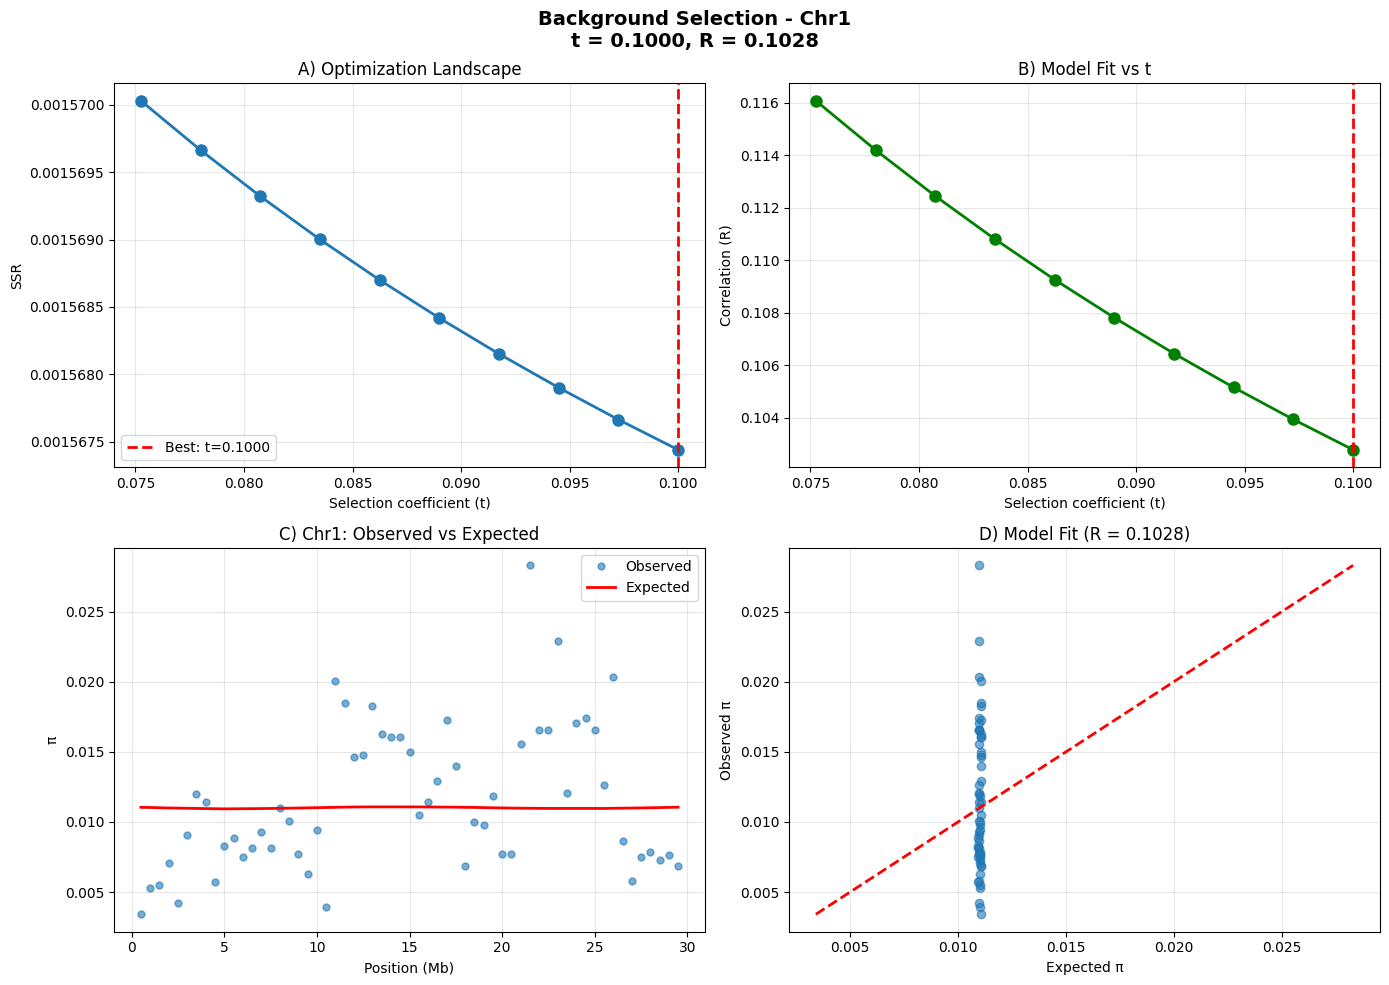


DONE!


In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from numba import jit

# ============================================
# CONFIGURATION
# ============================================
PARAMS = {
    'u_deleterious': 1e-9,           
    'F': 0.9,                         
    'focal_spacing': 500_000,         
    'max_distance_bp': 5_000_000,     
}

# ============================================
# STEP 1: LOAD DATA
# ============================================
print("=" * 70)
print("STEP 1: Loading data")
print("=" * 70)

recombination = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/01_data/crossover_data_mercier/female_male1mb_non_overlapping_crossovers.csv",
    sep="\t"
)
print(f"\n✓ Recombination map: {len(recombination)} windows")

pi_4fold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/03_results/pi_27g_orth_genes/4foldsites_500bp_precomputed.csv",
    sep="\t"
)
pi_4fold = pi_4fold.iloc[:, [0, 1, 3]]
pi_4fold.columns = ["Chr", "pos", "pi"]
print(f"✓ 4-fold sites (neutral): {len(pi_4fold)} sites, mean pi = {pi_4fold['pi'].mean():.6f}")

zerofold = pd.read_csv(
    "/groups/nordborg/projects/genome_organization/08_manuscripts/01_data/tair10/4fold/0_fold_sites.txt",
    sep="\t"
)
zerofold.columns = ["Chr", "pos"]
zerofold = zerofold.dropna()
print(f"✓ 0-fold sites (selected): {len(zerofold)} sites")

# ============================================
# STEP 2: OPTIMIZED HELPER FUNCTIONS
# ============================================
print("\n" + "=" * 70)
print("STEP 2: Setting up OPTIMIZED functions")
print("=" * 70)

@jit(nopython=True)
def calculate_genetic_distances_vectorized(focal_pos, selected_positions, 
                                           window_starts, window_ends, window_rates):
    """
    VECTORIZED: Calculate genetic distances from focal to all selected positions.
    Uses numba JIT compilation for massive speedup.
    
    Returns array of genetic distances in Morgans.
    """
    n_selected = len(selected_positions)
    r_values = np.zeros(n_selected)
    
    for i in range(n_selected):
        selected_pos = selected_positions[i]
        
        if focal_pos == selected_pos:
            r_values[i] = 0.0
            continue
        
        start = min(focal_pos, selected_pos)
        end = max(focal_pos, selected_pos)
        
        # Calculate genetic distance
        genetic_dist_cM = 0.0
        for j in range(len(window_starts)):
            if window_ends[j] > start and window_starts[j] < end:
                overlap_start = max(start, window_starts[j])
                overlap_end = min(end, window_ends[j])
                overlap_length_bp = overlap_end - overlap_start
                genetic_dist_cM += (overlap_length_bp / 1_000_000) * window_rates[j]
        
        r_values[i] = genetic_dist_cM / 100.0  # Convert to Morgans
    
    return r_values


@jit(nopython=True)
def calculate_B_vectorized(r_values, u, t, F):
    """
    VECTORIZED: Calculate B statistic given genetic distances.
    """
    denominator = (1 + ((1 - F) * r_values / t)) ** 2
    contributions = 1 - (u / t) / denominator
    return np.prod(contributions)


def calculate_B_map_for_chromosome_FAST(chrom, selected_sites, recomb_map, pi_data, t, params, verbose=True):
    """
    OPTIMIZED VERSION: Much faster B map calculation.
    """
    if verbose:
        print(f"\n  Calculating B map for {chrom} (t = {t:.4f})...")
    
    # Filter data for this chromosome
    recomb_chr = recomb_map[recomb_map['Chr'] == chrom].copy()
    selected_chr = selected_sites[selected_sites['Chr'] == chrom]['pos'].values
    pi_chr = pi_data[pi_data['Chr'] == chrom].copy()
    
    # Pre-convert recombination map to numpy arrays (for numba)
    window_starts = recomb_chr['start'].values
    window_ends = recomb_chr['end'].values
    window_rates = recomb_chr['avg_co'].values
    
    # Define focal sites
    max_pos = recomb_chr['end'].max()
    focal_positions = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    if verbose:
        print(f"    - {len(selected_chr):,} selected sites")
        print(f"    - {len(focal_positions)} focal sites")
    
    # Pre-compute which selected sites are within max_distance of ANY focal site
    # (This avoids recalculating distances for sites that are always too far)
    min_focal = focal_positions.min()
    max_focal = focal_positions.max()
    relevant_mask = (selected_chr >= min_focal - params['max_distance_bp']) & \
                    (selected_chr <= max_focal + params['max_distance_bp'])
    selected_chr_relevant = selected_chr[relevant_mask]
    
    if verbose:
        print(f"    - {len(selected_chr_relevant):,} selected sites within range")
    
    u = params['u_deleterious']
    F = params['F']
    
    results = []
    for i, focal_pos in enumerate(focal_positions):
        if verbose and (i + 1) % 5 == 0:
            print(f"    - Progress: {i+1}/{len(focal_positions)}", end='\r')
        
        # Filter to nearby selected sites
        distances = np.abs(selected_chr_relevant - focal_pos)
        nearby_mask = distances <= params['max_distance_bp']
        nearby_positions = selected_chr_relevant[nearby_mask]
        
        if len(nearby_positions) == 0:
            B = 1.0
        else:
            # Calculate genetic distances (vectorized)
            r_values = calculate_genetic_distances_vectorized(
                focal_pos, nearby_positions, 
                window_starts, window_ends, window_rates
            )
            
            # Calculate B (vectorized)
            B = calculate_B_vectorized(r_values, u, t, F)
        
        # Get observed pi
        nearest_idx = (pi_chr['pos'] - focal_pos).abs().idxmin()
        pi_obs = pi_chr.loc[nearest_idx, 'pi']
        
        results.append({
            'position': focal_pos,
            'B_expected': B,
            'pi_observed': pi_obs
        })
    
    if verbose:
        print(f"    - Progress: {len(focal_positions)}/{len(focal_positions)} ✓")
    
    return pd.DataFrame(results)


def objective_function_FAST(t, chrom, selected_sites, recomb_map, pi_data, params, verbose=True):
    """
    OPTIMIZED objective function.
    """
    df = calculate_B_map_for_chromosome_FAST(chrom, selected_sites, recomb_map, pi_data, t, params, verbose=verbose)
    
    mean_pi = pi_data[pi_data['Chr'] == chrom]['pi'].mean()
    df['pi_expected'] = df['B_expected'] * mean_pi
    
    ssr = np.sum((df['pi_observed'] - df['pi_expected']) ** 2)
    
    if verbose:
        print(f"  SSR = {ssr:.8f}")
    
    return ssr


# ============================================
# STEP 3: COARSE GRID SEARCH (FAST)
# ============================================
print("\n" + "=" * 70)
print("STEP 3: COARSE Grid Search (5 values)")
print("=" * 70)

TEST_CHROM = 'Chr1'

print(f"\nPerforming COARSE grid search for {TEST_CHROM}...")
print("Testing 5 values to quickly find the ballpark.\n")

# COARSE grid: only 5 values
t_grid_coarse = np.linspace(0.001, 0.1, 5)
ssr_grid_coarse = []

print(f"Testing {len(t_grid_coarse)} values of t:")
print("-" * 70)

import time
for i, t in enumerate(t_grid_coarse):
    print(f"\n[{i+1}/{len(t_grid_coarse)}] Testing t = {t:.4f}")
    start_time = time.time()
    
    ssr = objective_function_FAST(t, TEST_CHROM, zerofold, recombination, pi_4fold, PARAMS, verbose=False)
    ssr_grid_coarse.append(ssr)
    
    elapsed = time.time() - start_time
    print(f"    SSR = {ssr:.8f} (took {elapsed:.1f} seconds)")

# Find best region
best_idx_coarse = np.argmin(ssr_grid_coarse)
best_t_coarse = t_grid_coarse[best_idx_coarse]

print("\n" + "=" * 70)
print(f"COARSE GRID RESULT: Best t ≈ {best_t_coarse:.4f}")
print("=" * 70)

# ============================================
# STEP 4: FINE GRID SEARCH (around best value)
# ============================================
print("\n" + "=" * 70)
print("STEP 4: FINE Grid Search (10 values around best)")
print("=" * 70)

# Define fine grid around the coarse best value
if best_idx_coarse == 0:
    fine_range = (t_grid_coarse[0], t_grid_coarse[1])
elif best_idx_coarse == len(t_grid_coarse) - 1:
    fine_range = (t_grid_coarse[-2], t_grid_coarse[-1])
else:
    fine_range = (t_grid_coarse[best_idx_coarse - 1], t_grid_coarse[best_idx_coarse + 1])

t_grid_fine = np.linspace(fine_range[0], fine_range[1], 10)
ssr_grid_fine = []
correlation_grid_fine = []
mean_B_grid_fine = []

print(f"\nTesting {len(t_grid_fine)} values between {fine_range[0]:.4f} and {fine_range[1]:.4f}:")
print("-" * 70)

for i, t in enumerate(t_grid_fine):
    print(f"\n[{i+1}/{len(t_grid_fine)}] Testing t = {t:.4f}")
    start_time = time.time()
    
    ssr = objective_function_FAST(t, TEST_CHROM, zerofold, recombination, pi_4fold, PARAMS, verbose=False)
    ssr_grid_fine.append(ssr)
    
    # Calculate additional metrics
    df_temp = calculate_B_map_for_chromosome_FAST(TEST_CHROM, zerofold, recombination, pi_4fold, t, PARAMS, verbose=False)
    mean_pi = pi_4fold[pi_4fold['Chr'] == TEST_CHROM]['pi'].mean()
    df_temp['pi_expected'] = df_temp['B_expected'] * mean_pi
    
    corr = np.corrcoef(df_temp['pi_observed'], df_temp['pi_expected'])[0, 1]
    mean_B = df_temp['B_expected'].mean()
    
    correlation_grid_fine.append(corr)
    mean_B_grid_fine.append(mean_B)
    
    elapsed = time.time() - start_time
    print(f"    SSR = {ssr:.8f}, R = {corr:.4f}, Mean B = {mean_B:.4f} ({elapsed:.1f}s)")

best_idx_fine = np.argmin(ssr_grid_fine)
best_t_fine = t_grid_fine[best_idx_fine]
best_ssr_fine = ssr_grid_fine[best_idx_fine]

print("\n" + "=" * 70)
print(f"FINE GRID RESULT: Best t = {best_t_fine:.4f} (SSR = {best_ssr_fine:.8f})")
print("=" * 70)

# ============================================
# STEP 5: PRECISE OPTIMIZATION
# ============================================
print("\n" + "=" * 70)
print("STEP 5: Precise optimization using scipy")
print("=" * 70)

print(f"\nUsing bounded optimization around t = {best_t_fine:.4f}...\n")

result = minimize_scalar(
    objective_function_FAST,
    bounds=(fine_range[0], fine_range[1]),
    method='bounded',
    args=(TEST_CHROM, zerofold, recombination, pi_4fold, PARAMS, False)
)

best_t_precise = result.x
best_ssr_precise = result.fun

print(f"\n{'='*70}")
print(f"PRECISE RESULT: t = {best_t_precise:.6f} (SSR = {best_ssr_precise:.8f})")
print(f"{'='*70}")

# ============================================
# STEP 6: GENERATE FINAL RESULTS
# ============================================
print("\n" + "=" * 70)
print("STEP 6: Generating final B map")
print("=" * 70)

final_df = calculate_B_map_for_chromosome_FAST(
    TEST_CHROM, zerofold, recombination, pi_4fold, best_t_precise, PARAMS
)

mean_pi = pi_4fold[pi_4fold['Chr'] == TEST_CHROM]['pi'].mean()
final_df['pi_expected'] = final_df['B_expected'] * mean_pi

correlation_final = np.corrcoef(final_df['pi_observed'], final_df['pi_expected'])[0, 1]
mean_B_final = final_df['B_expected'].mean()
diversity_reduction = (1 - mean_B_final) * 100

print(f"\nFinal Statistics:")
print(f"  - Best t: {best_t_precise:.6f}")
print(f"  - Correlation: {correlation_final:.4f}")
print(f"  - Mean B: {mean_B_final:.4f}")
print(f"  - Diversity reduction: {diversity_reduction:.1f}%")

# Save
output_file = f"background_selection_{TEST_CHROM}_results.csv"
final_df.to_csv(output_file, index=False)
print(f"\n✓ Results saved to: {output_file}")

# ============================================
# STEP 7: PLOT
# ============================================
print("\n" + "=" * 70)
print("STEP 7: Creating plots")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fine grid optimization landscape
ax1 = axes[0, 0]
ax1.plot(t_grid_fine, ssr_grid_fine, 'o-', linewidth=2, markersize=8)
ax1.axvline(best_t_precise, color='red', linestyle='--', linewidth=2, label=f'Best: t={best_t_precise:.4f}')
ax1.set_xlabel('Selection coefficient (t)')
ax1.set_ylabel('SSR')
ax1.set_title('A) Optimization Landscape')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Correlation vs t
ax2 = axes[0, 1]
ax2.plot(t_grid_fine, correlation_grid_fine, 'o-', linewidth=2, markersize=8, color='green')
ax2.axvline(best_t_precise, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Selection coefficient (t)')
ax2.set_ylabel('Correlation (R)')
ax2.set_title('B) Model Fit vs t')
ax2.grid(alpha=0.3)

# Plot 3: Diversity along chromosome
ax3 = axes[1, 0]
ax3.plot(final_df['position'] / 1e6, final_df['pi_observed'], 'o', alpha=0.6, label='Observed', markersize=5)
ax3.plot(final_df['position'] / 1e6, final_df['pi_expected'], '-', linewidth=2, label='Expected', color='red')
ax3.set_xlabel('Position (Mb)')
ax3.set_ylabel('π')
ax3.set_title(f'C) {TEST_CHROM}: Observed vs Expected')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Observed vs Expected
ax4 = axes[1, 1]
ax4.scatter(final_df['pi_expected'], final_df['pi_observed'], alpha=0.6)
min_val = min(final_df['pi_expected'].min(), final_df['pi_observed'].min())
max_val = max(final_df['pi_expected'].max(), final_df['pi_observed'].max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax4.set_xlabel('Expected π')
ax4.set_ylabel('Observed π')
ax4.set_title(f'D) Model Fit (R = {correlation_final:.4f})')
ax4.grid(alpha=0.3)

plt.suptitle(f'Background Selection - {TEST_CHROM}\nt = {best_t_precise:.4f}, R = {correlation_final:.4f}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'background_selection_{TEST_CHROM}_optimized.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Plot saved")
plt.show()

print("\n" + "=" * 70)
print("DONE!")
print("=" * 70)

### Visualize the best prediction of selection coefficient

Creating combined plot for all chromosomes with custom 'ggplot' style...
Processing Chr1...


NameError: name 'generate_final_plot_data' is not defined

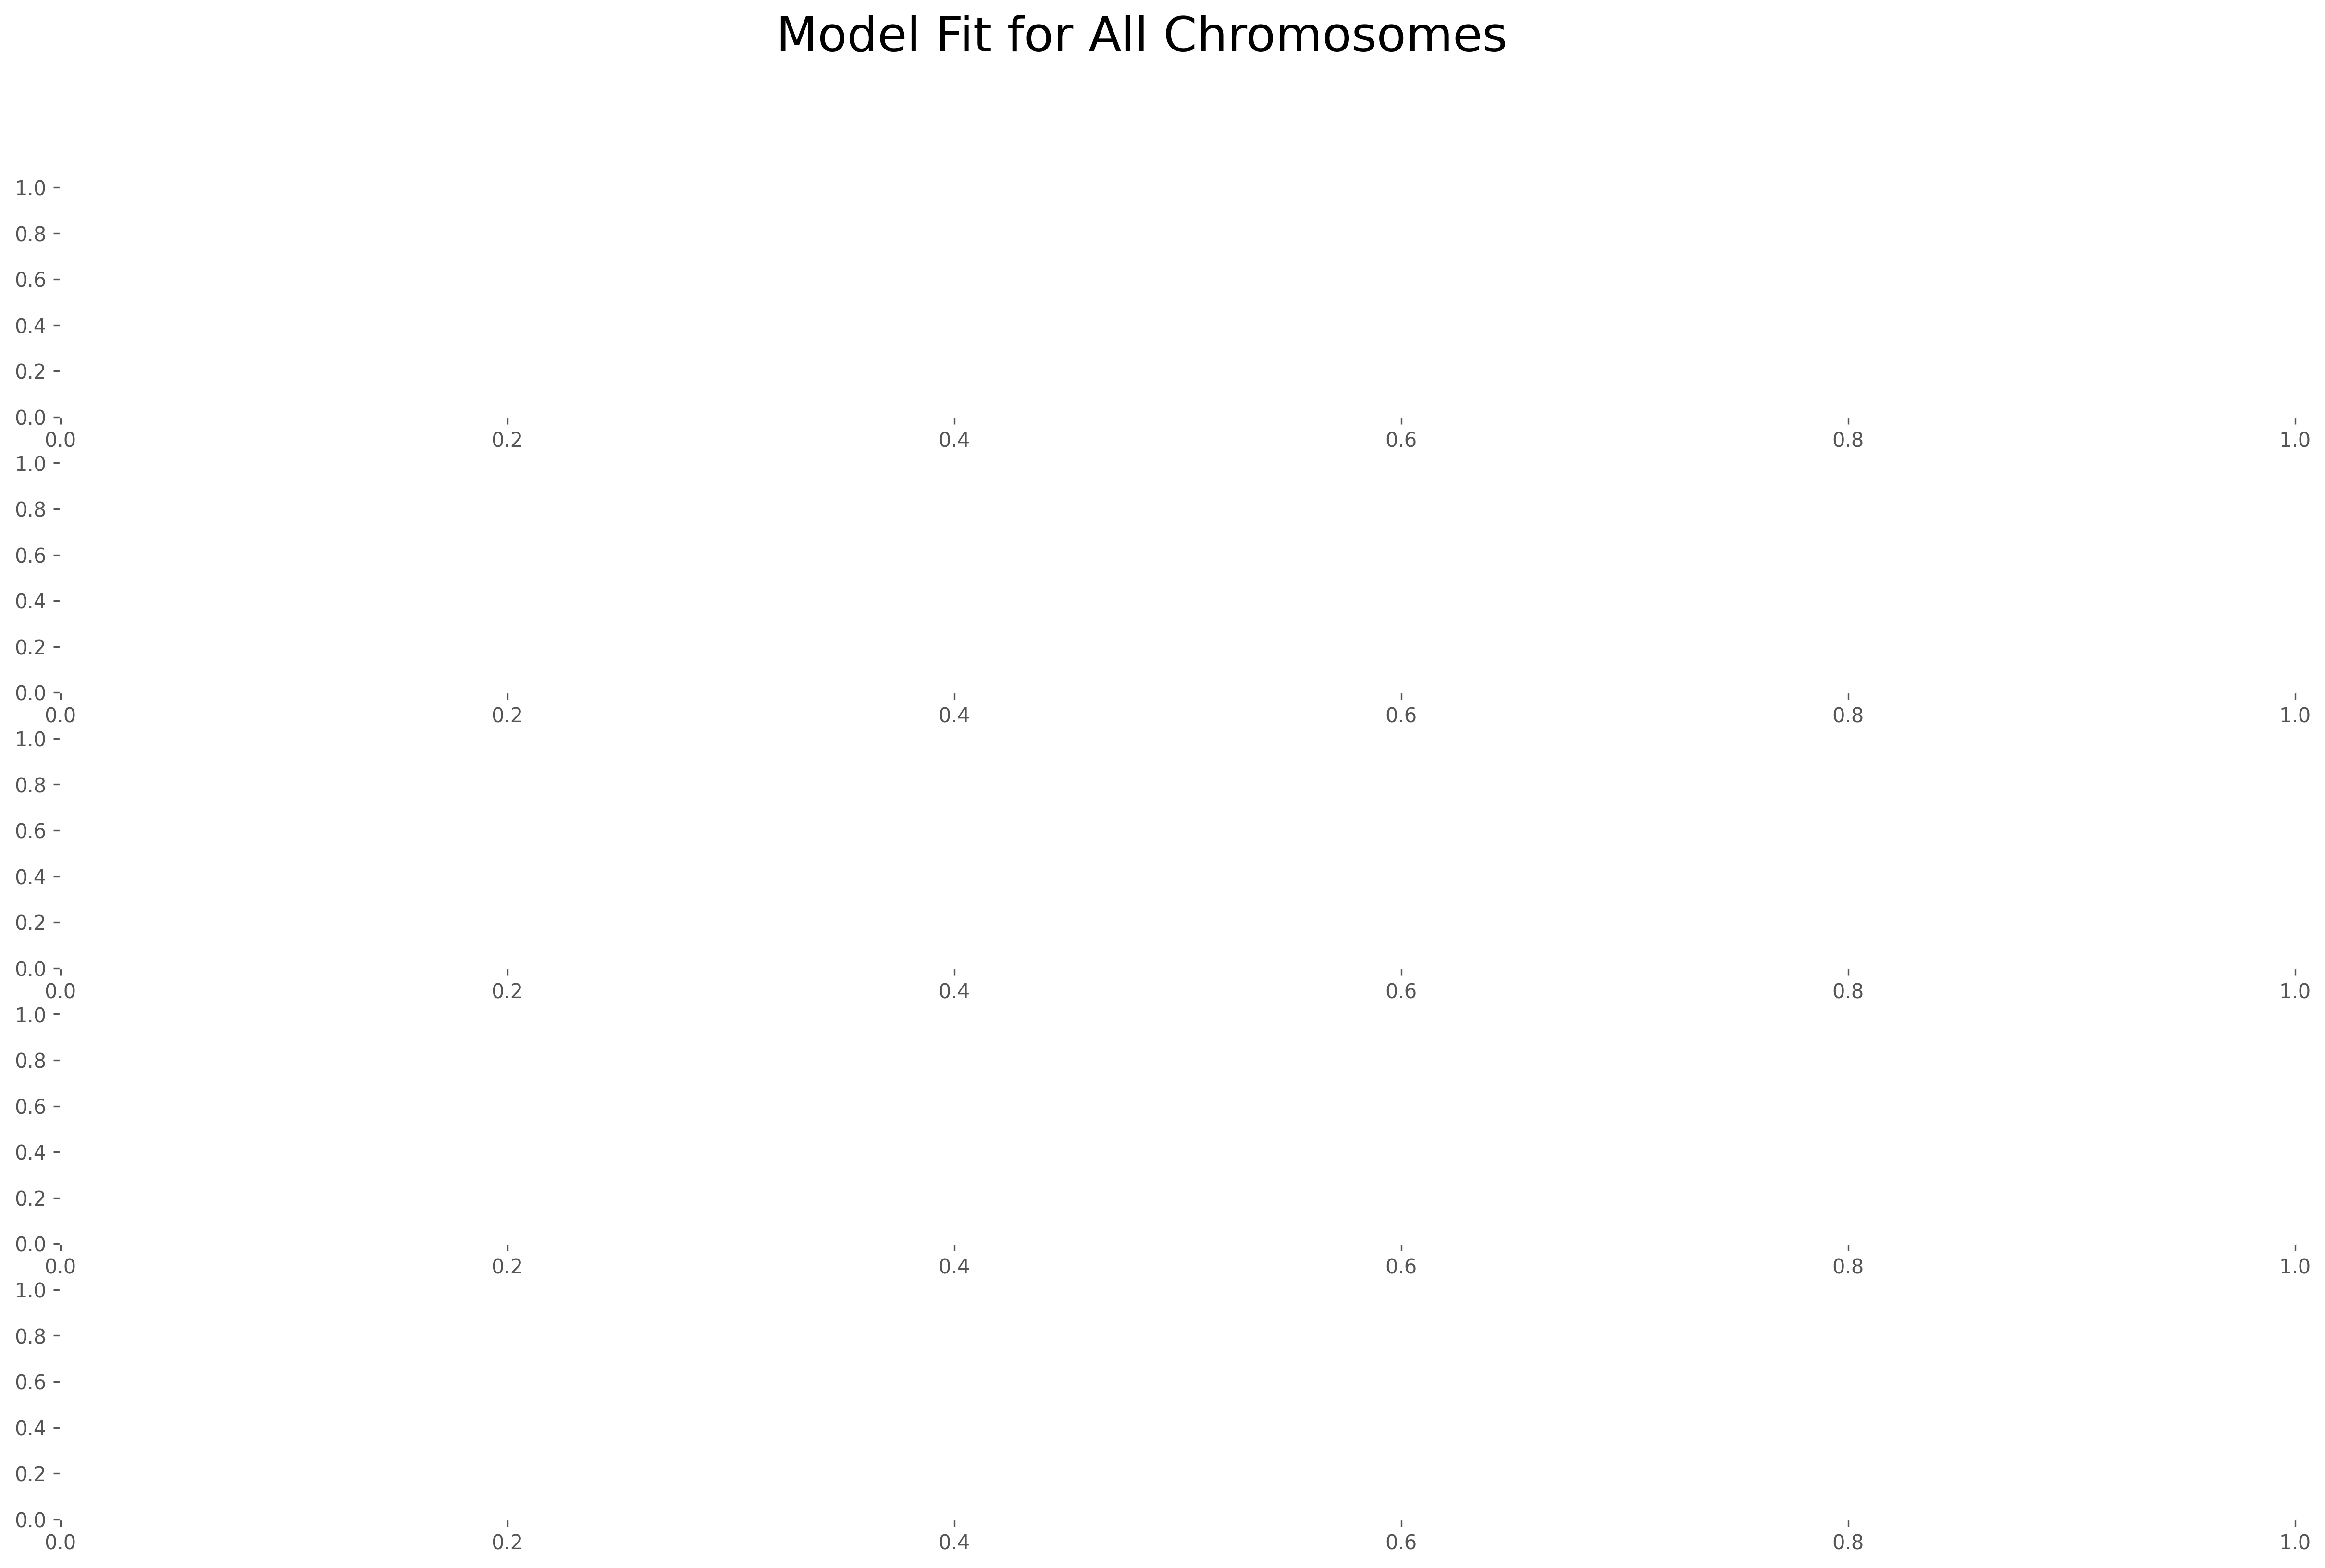

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Your best results DataFrame (the one you showed)
best_results = pd.DataFrame({
    'chromosome': ['Chr1', 'Chr2', 'Chr3', 'Chr4','Chr5'],
    't_mean': [0.006, 0.041, 0.011, 0.026, 0.296],
    'correlation': [0.470625, 0.255146, 0.527150, 0.152173, 0.404573],
    'rmse': [0.987800, 0.990081, 0.989692, 0.986, 0.98826]
})


# Apply the base style
plt.style.use('ggplot')

print("Creating combined plot for all chromosomes with custom 'ggplot' style...")

# Create subplots - 2x2 grid for 4 chromosomes
fig, axes = plt.subplots(5, 1, figsize=(20, 12), dpi=300)

axes = axes.flatten()  # Make it easier to iterate

# Set background colors
fig.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

# Set overall title
fig.suptitle('Model Fit for All Chromosomes', fontsize=24)

# Process each chromosome
for i, (_, row) in enumerate(best_results.iterrows()):
    TARGET_CHROM = row['chromosome']
    BEST_T_VALUE = row['t_mean']
    
    print(f"Processing {TARGET_CHROM}...")
    
    # Generate plot data for this chromosome
    plot_dataframe = generate_final_plot_data(
        chrom=TARGET_CHROM,
        best_t=BEST_T_VALUE,
        params=ANALYSIS_PARAMS,
        selected_sites_df=selected_sites_df,
        recombination_df=recombination,
        pi_4fold_df=pi_in_4_fold_sites
    )
    
    # Get the current subplot
    ax1 = axes[i]
    ax1.set_title(f'{TARGET_CHROM} (Best t = {BEST_T_VALUE:.3f})', fontsize=16)
    
    # Plot 1: Predicted Diversity (B)
    color1 = 'royalblue'
    ax1.set_xlabel('Chromosome Position', fontsize=12)
    ax1.set_ylabel('Pairwise coalescence', color=color1, fontsize=12)
    ax1.plot(plot_dataframe['position'], plot_dataframe['expected_pi'], 
             color=color1, marker='o', linestyle='-', markersize=3, label='Predicted (B)')
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Create the second y-axis
    ax2 = ax1.twinx()
    
    # Plot 2: Observed Diversity (π)
    color2 = 'forestgreen'
    ax2.set_ylabel('Observed Diversity (π)', color=color2, fontsize=12)
    ax2.plot(plot_dataframe['position'], plot_dataframe['observed_pi'], 
             color=color2, marker='o', linestyle='-', markersize=3, label='Observed (π)')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Format x-axis
    formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:.1f} Mb')
    ax1.xaxis.set_major_formatter(formatter)
    
    # Add legend only to the first subplot to avoid clutter
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



In [4]:
results_df = pd.read_csv('/groups/nordborg/projects/genome_organization/02_scripts/all_selection_results.csv')

In [13]:
# Sort by correlation in descending order (highest first)
results_df.loc[results_df.groupby('chromosome')['correlation'].idxmax()]


,chromosome,t_mean,correlation,rmse
1,Chr1,0.006,0.470625,0.987800
68,Chr2,0.041,0.255146,0.990081
122,Chr3,0.011,0.527150,0.989692
185,Chr4,0.026,0.152173,0.986892
299,Chr5,0.296,0.404573,0.988265


In [6]:
ANALYSIS_PARAMS = {
    'u_deleterious': 1e-9,
    'F': 0.9,
    'focal_spacing': 500_000,
    # This value should match what you used in your final analysis
    'max_selected_sites_per_focal': 10000
}

# --- Helper functions copied from your analysis script ---
def calculate_genetic_distance_cM_FAST(focal_pos, selected_pos, chr_recomb_data):
    if focal_pos == selected_pos: return 0.0
    start_interval, end_interval = min(focal_pos, selected_pos), max(focal_pos, selected_pos)
    relevant_windows = chr_recomb_data[(chr_recomb_data['end'] > start_interval) & (chr_recomb_data['start'] < end_interval)]
    if relevant_windows.empty: return 0.0
    overlap_starts = np.maximum(start_interval, relevant_windows['start'].values)
    overlap_ends = np.minimum(end_interval, relevant_windows['end'].values)
    overlap_lengths_bp = overlap_ends - overlap_starts
    total_genetic_distance_cM = np.sum((overlap_lengths_bp / 1_000_000) * relevant_windows['avg_co'].values)
    return total_genetic_distance_cM

def calculate_B_at_focal_site(focal_pos, selected_positions_chr, recomb_map_chr,
                              u_deleterious, t_mean, F,
                              max_selected_sites_per_focal):
    distances = np.abs(selected_positions_chr - focal_pos)
    if len(selected_positions_chr) > max_selected_sites_per_focal:
        closest_indices = np.argsort(distances)[:max_selected_sites_per_focal]
        nearby_positions = selected_positions_chr[closest_indices]
    else:
        nearby_positions = selected_positions_chr
    r_values = np.array([calculate_genetic_distance_cM_FAST(focal_pos, pos, recomb_map_chr) for pos in nearby_positions])
    denominator = (1 + (((1 - F) * r_values) / t_mean))**2
    contributions = 1 - ((u_deleterious / t_mean) / denominator)
    return np.prod(contributions)

def get_local_diversity(focal_pos, pi_4fold_chr_map):
    closest_window_idx = (pi_4fold_chr_map['pos'] - focal_pos).abs().idxmin()
    return pi_4fold_chr_map.loc[closest_window_idx, 'pi']

def generate_final_plot_data(chrom, best_t, params, selected_sites_df, recombination_df, pi_4fold_df):
    """Generates the data needed for the final plot by recalculating B and pi."""
    print(f"Generating plot data for {chrom} using best t = {best_t:.4f}... (This will take several minutes)")
    chr_sites_df = selected_sites_df[selected_sites_df['Chr'] == chrom]
    recomb_map_chr = recombination_df[recombination_df['Chr'] == chrom]
    pi_4fold_chr = pi_4fold_df[pi_4fold_df['Chr'] == chrom]
    selected_pos_array = chr_sites_df[chr_sites_df['is_selected']]['pos'].values
    
    max_pos = chr_sites_df['pos'].max()
    focal_sites = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    plot_data = []
    for pos in focal_sites:
        expected_pi = calculate_B_at_focal_site(
            pos, selected_pos_array, recomb_map_chr,
            params['u_deleterious'], best_t, params['F'],
            params['max_selected_sites_per_focal']
        )
        observed_pi = get_local_diversity(pos, pi_4fold_chr)
        plot_data.append({'position': pos, 'expected_pi': expected_pi, 'observed_pi': observed_pi})
        
    return pd.DataFrame(plot_data)

Loading data...
Data loaded successfully.
Generating plot data for Chr1 using best t = 0.0060... (This will take several minutes)
Calculation complete. Creating plot...


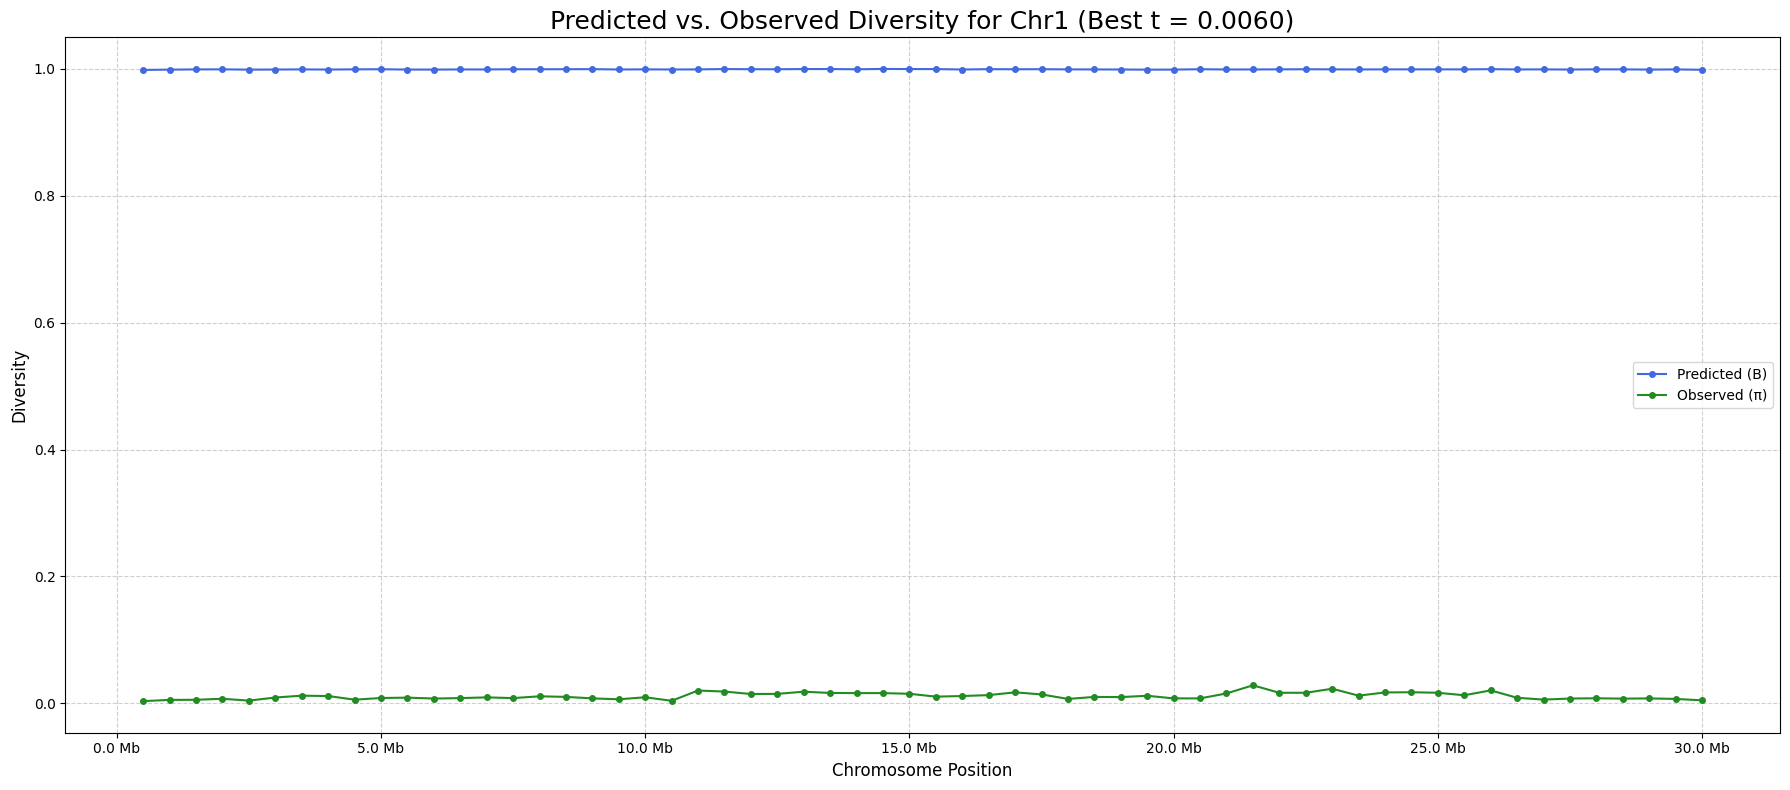

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==============================================================================
# STEP 1: LOAD ALL NECESSARY DATA
# ==============================================================================
# This script needs BOTH your final results file AND your original input files.

print("Loading data...")
# --- 1a. Load your final results CSV ---
try:
    # Make sure this path is correct
    results_df = pd.read_csv('/groups/nordborg/projects/genome_organization/02_scripts/all_selection_results.csv')
except FileNotFoundError:
    print("Error: 'all_selection_results.csv' not found. Please check the filename.")
    exit()
try:
    # Your recombination map file
    recombination_df = recombination
    # Your file with pi calculated in windows
except FileNotFoundError as e:
    print(f"Error loading original data files: {e}")
    print("Please ensure the original input data files are available and paths are correct.")
    exit()

print("Data loaded successfully.")


# ==============================================================================
# STEP 2: RE-DEFINE PARAMETERS AND HELPER FUNCTIONS (Unchanged)
# ==============================================================================
# We need to copy these from your main analysis script so this plotting script
# can work independently.

ANALYSIS_PARAMS = {
    'u_deleterious': 1e-9,
    'F': 0.9,
    'focal_spacing': 500_000,
    # This value should match what you used in your final analysis
    'max_selected_sites_per_focal': 10000
}

# --- Helper functions copied from your analysis script ---
def calculate_genetic_distance_cM_FAST(focal_pos, selected_pos, chr_recomb_data):
    if focal_pos == selected_pos: return 0.0
    start_interval, end_interval = min(focal_pos, selected_pos), max(focal_pos, selected_pos)
    relevant_windows = chr_recomb_data[(chr_recomb_data['end'] > start_interval) & (chr_recomb_data['start'] < end_interval)]
    if relevant_windows.empty: return 0.0
    overlap_starts = np.maximum(start_interval, relevant_windows['start'].values)
    overlap_ends = np.minimum(end_interval, relevant_windows['end'].values)
    overlap_lengths_bp = overlap_ends - overlap_starts
    total_genetic_distance_cM = np.sum((overlap_lengths_bp / 1_000_000) * relevant_windows['avg_co'].values)
    return total_genetic_distance_cM

def calculate_B_at_focal_site(focal_pos, selected_positions_chr, recomb_map_chr,
                              u_deleterious, t_mean, F,
                              max_selected_sites_per_focal):
    distances = np.abs(selected_positions_chr - focal_pos)
    if len(selected_positions_chr) > max_selected_sites_per_focal:
        closest_indices = np.argsort(distances)[:max_selected_sites_per_focal]
        nearby_positions = selected_positions_chr[closest_indices]
    else:
        nearby_positions = selected_positions_chr
    r_values = np.array([calculate_genetic_distance_cM_FAST(focal_pos, pos, recomb_map_chr) for pos in nearby_positions])
    denominator = (1 + (((1 - F) * r_values) / t_mean))**2
    contributions = 1 - ((u_deleterious / t_mean) / denominator)
    return np.prod(contributions)

def get_local_diversity(focal_pos, pi_4fold_chr_map):
    closest_window_idx = (pi_4fold_chr_map['pos'] - focal_pos).abs().idxmin()
    return pi_4fold_chr_map.loc[closest_window_idx, 'pi']

def generate_final_plot_data(chrom, best_t, params, selected_sites_df, recombination_df, pi_4fold_df):
    """Generates the data needed for the final plot by recalculating B and pi."""
    print(f"Generating plot data for {chrom} using best t = {best_t:.4f}... (This will take several minutes)")
    chr_sites_df = selected_sites_df[selected_sites_df['Chr'] == chrom]
    recomb_map_chr = recombination_df[recombination_df['Chr'] == chrom]
    pi_4fold_chr = pi_4fold_df[pi_4fold_df['Chr'] == chrom]
    selected_pos_array = chr_sites_df[chr_sites_df['is_selected']]['pos'].values
    
    max_pos = chr_sites_df['pos'].max()
    focal_sites = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    plot_data = []
    for pos in focal_sites:
        expected_pi = calculate_B_at_focal_site(
            pos, selected_pos_array, recomb_map_chr,
            params['u_deleterious'], best_t, params['F'],
            params['max_selected_sites_per_focal']
        )
        observed_pi = get_local_diversity(pos, pi_4fold_chr)
        plot_data.append({'position': pos, 'expected_pi': expected_pi, 'observed_pi': observed_pi})
        
    return pd.DataFrame(plot_data)


# ==============================================================================
# STEP 3: FIND BEST PARAMETERS AND GENERATE PLOT
# ==============================================================================

TARGET_CHROM = 'Chr1'  # Choose which chromosome you want to visualize

try:
    target_chrom_results = results_df[results_df['chromosome'] == TARGET_CHROM]
    if target_chrom_results.empty:
        raise KeyError
    best_row = target_chrom_results.loc[target_chrom_results['correlation'].idxmax()]
    BEST_T_VALUE = best_row['t_mean']
except KeyError:
    print(f"Error: Could not find results for {TARGET_CHROM} in the CSV file.")
    exit()
    
# This part also remains the same. It will still take time to run.
plot_dataframe = generate_final_plot_data(
    chrom=TARGET_CHROM,
    best_t=BEST_T_VALUE,
    params=ANALYSIS_PARAMS,
    selected_sites_df=selected_sites_df,
    recombination_df=recombination_df,
    pi_4fold_df=pi_in_4_fold_sites
)

# ==============================================================================
# --- MODIFIED PLOTTING CODE: Predicted vs. Observed on a Single Plot ---
# ==============================================================================
print("Calculation complete. Creating plot...")

# Create a single plot instead of two subplots
fig, ax = plt.subplots(figsize=(18, 8)) 

# --- Plot both lines on the SAME axis (ax) ---
# Plot 1: Predicted Diversity (B)
ax.plot(plot_dataframe['position'], plot_dataframe['expected_pi'], 
        color='royalblue', marker='o', linestyle='-', markersize=4, label='Predicted (B)')

# Plot 2: Observed Diversity (π)
ax.plot(plot_dataframe['position'], plot_dataframe['observed_pi'], 
        color='forestgreen', marker='o', linestyle='-', markersize=4, label='Observed (π)')

# --- Add labels and a title for the single plot ---
ax.set_title(f'Predicted vs. Observed Diversity for {TARGET_CHROM} (Best t = {BEST_T_VALUE:.4f})', fontsize=18)
ax.set_ylabel('Diversity', fontsize=12)
ax.set_xlabel('Chromosome Position', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# A single legend will automatically include both lines
ax.legend()

# Format the shared x-axis to show Megabases (Mb)
formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:.1f} Mb')
ax.xaxis.set_major_formatter(formatter)

# Improve layout and show the plot
plt.tight_layout()
plt.show()

In [3]:
selected_sites_df.head()

,Chr,pos,is_selected
0,Chr1,1,False
1,Chr1,2,False
2,Chr1,3,False
3,Chr1,4,False
4,Chr1,5,False


In [4]:
list(np.arange(0.001, 0.3, 0.005))

[0.001,
 0.006,
 0.011,
 0.016,
 0.021,
 0.026000000000000002,
 0.031,
 0.036000000000000004,
 0.041,
 0.046,
 0.051000000000000004,
 0.056,
 0.061,
 0.066,
 0.07100000000000001,
 0.076,
 0.081,
 0.08600000000000001,
 0.091,
 0.096,
 0.101,
 0.106,
 0.111,
 0.116,
 0.121,
 0.126,
 0.131,
 0.136,
 0.14100000000000001,
 0.146,
 0.151,
 0.156,
 0.161,
 0.166,
 0.171,
 0.17600000000000002,
 0.181,
 0.186,
 0.191,
 0.196,
 0.201,
 0.20600000000000002,
 0.211,
 0.216,
 0.221,
 0.226,
 0.231,
 0.23600000000000002,
 0.241,
 0.246,
 0.251,
 0.256,
 0.261,
 0.266,
 0.271,
 0.276,
 0.281,
 0.28600000000000003,
 0.291,
 0.296]

### Calculate recombination rate
##### Step 1. get recombination rate at the focal positions

In [6]:
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
import time
import os

###
# ==============================================================================
# STEP 1: DATA LOADING (This should be your existing data loading section)
# ==============================================================================
# This section is a placeholder. Please ensure you have loaded your data
# into these pandas DataFrames before running the script.

# print("Loading data...")
# selected_sites_df = pd.read_csv('path/to/your/all_sites_with_selection_info.csv')
# recombination = pd.read_csv('path/to/your/recombination_map.csv')
# pi_in_4_fold_sites = pd.read_csv('path/to/your/pi_in_4fold_windows.csv')
# print("Data loaded successfully.")

###
# ==============================================================================
# STEP 2: HELPER FUNCTIONS (With the critical speed optimization)
# ==============================================================================

# <-- THE CRITICAL OPTIMIZATION: This fast version replaces your old distance function.
def calculate_genetic_distance_cM_FAST(focal_pos, selected_pos, chr_recomb_data):
    """VECTORIZED version. Calculates genetic distance without Python loops."""
    if focal_pos == selected_pos:
        return 0.0
    start_interval, end_interval = min(focal_pos, selected_pos), max(focal_pos, selected_pos)
    relevant_windows = chr_recomb_data[(chr_recomb_data['end'] > start_interval) & (chr_recomb_data['start'] < end_interval)]
    if relevant_windows.empty:
        return 0.0
    overlap_starts = np.maximum(start_interval, relevant_windows['start'].values)
    overlap_ends = np.minimum(end_interval, relevant_windows['end'].values)
    overlap_lengths_bp = overlap_ends - overlap_starts
    total_genetic_distance_cM = np.sum((overlap_lengths_bp / 1_000_000) * relevant_windows['avg_co'].values)
    return total_genetic_distance_cM

# This is your original function, but it now calls the FAST version.
def calculate_B_at_focal_site(focal_pos, selected_positions_chr, recomb_map_chr,
                              u_deleterious, t_mean, F,
                              max_selected_sites_per_focal):
    distances = np.abs(selected_positions_chr - focal_pos)
    if len(selected_positions_chr) > max_selected_sites_per_focal:
        closest_indices = np.argsort(distances)[:max_selected_sites_per_focal]
        nearby_positions = selected_positions_chr[closest_indices]
    else:
        nearby_positions = selected_positions_chr
    
    # <-- USES THE FAST, VECTORIZED FUNCTION
    r_values = np.array([
        calculate_genetic_distance_cM_FAST(focal_pos, pos, recomb_map_chr) 
        for pos in nearby_positions
    ])
    
    denominator = (1 + (((1 - F) * r_values) / t_mean))**2
    contributions = 1 - ((u_deleterious / t_mean) / denominator)
    return np.prod(contributions)

# This function is from your original logic and does not need to change.
def get_local_diversity(focal_pos, pi_4fold_chr_map):
    """Gets pre-computed local diversity by finding the closest window center."""
    closest_window_idx = (pi_4fold_chr_map['pos'] - focal_pos).abs().idxmin()
    return pi_4fold_chr_map.loc[closest_window_idx, 'pi']

###
# ==============================================================================
# STEP 3: THE ANALYSIS ENGINE (Your original functions, unchanged)
# ==============================================================================

def process_site_worker(args):
    """Worker now receives the full params dict."""
    focal_pos, selected_pos_arr, recomb_map, pi_map, t_test, params = args
    B = calculate_B_at_focal_site(
        focal_pos=focal_pos, selected_positions_chr=selected_pos_arr,
        recomb_map_chr=recomb_map, u_deleterious=params['u_deleterious'],
        t_mean=t_test, F=params['F'],
        max_selected_sites_per_focal=params['max_selected_sites_per_focal']
    )
    local_pi = get_local_diversity(focal_pos, pi_map)
    return B, local_pi

def optimize_selection_coefficient(recombination_df, pi_4fold_df, chrom,
                                   selected_pos_array, focal_sites_chr, params, n_jobs):
    """The main optimization loop for a single chromosome with progress bars."""
    recomb_map_chr = recombination_df[recombination_df['Chr'] == chrom]
    pi_4fold_chr = pi_4fold_df[pi_4fold_df['Chr'] == chrom]
    results = []
    t_progress = tqdm(params['t_values'], desc=f"Optimizing t for {chrom}", unit="coeff")
    for t_test in t_progress:
        args_list = [(pos, selected_pos_array, recomb_map_chr, pi_4fold_chr, t_test, params) for pos in focal_sites_chr]
        results_list = []
        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            futures = [executor.submit(process_site_worker, arg) for arg in args_list]
            site_progress = tqdm(as_completed(futures), total=len(args_list), desc=f"  Sites (t={t_test:.4f})", leave=False)
            for future in site_progress:
                results_list.append(future.result())
        B_values, observed_pi = zip(*results_list)
        B_values, observed_pi = np.array(B_values), np.array(observed_pi)
        valid_mask = ~(np.isnan(B_values) | np.isnan(observed_pi))
        if np.sum(valid_mask) > 1:
            corr = np.corrcoef(B_values[valid_mask], observed_pi[valid_mask])[0, 1]
            results.append({'t_mean': t_test, 'correlation': corr})
            valid_corrs = [r['correlation'] for r in results if not np.isnan(r['correlation'])]
            if valid_corrs:
                t_progress.set_postfix(best_corr=f"{max(valid_corrs):.3f}")
        else:
            results.append({'t_mean': t_test, 'correlation': np.nan})
    return pd.DataFrame(results)

###
# ==============================================================================
# STEP 4: RUN THE ANALYSIS (Your original code with optimal n_jobs)
# ==============================================================================

ANALYSIS_PARAMS = {
    'u_deleterious': 1e-9,
    'F': 0.9,
    'focal_spacing': 500_000,
    't_values': list(np.arange(0.001, 0.3, 0.005)),
    'max_selected_sites_per_focal': 10000
}

# <-- SECOND OPTIMIZATION: Use the correct number of workers for your machine.
try:
    N_JOBS = len(os.sched_getaffinity(0))
except AttributeError:
    N_JOBS = os.cpu_count() or 1 # Fallback for non-Linux/Windows or if detection fails
print(f"Using {N_JOBS} parallel workers (matches available CPU cores).")

chromosomes_to_run = ['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5']
all_results = {}

print("\nStarting Background Selection Analysis...")
print(f"Using downsampling: {ANALYSIS_PARAMS['max_selected_sites_per_focal']} closest selected sites per focal site.")

for chrom in chromosomes_to_run:
    chr_sites_df = selected_sites_df[selected_sites_df['Chr'] == chrom]
    selected_sites_on_chr = chr_sites_df[chr_sites_df['is_selected']]
    selected_pos_array = selected_sites_on_chr['pos'].values
    
    max_pos = chr_sites_df['pos'].max()
    focal_sites_for_chr = np.arange(ANALYSIS_PARAMS['focal_spacing'], max_pos, ANALYSIS_PARAMS['focal_spacing'])
    
    print(f"\nProcessing {chrom} with {len(focal_sites_for_chr)} focal sites...")
    
    all_results[chrom] = optimize_selection_coefficient(
        recombination_df=recombination, 
        pi_4fold_df=pi_in_4_fold_sites,
        chrom=chrom, 
        selected_pos_array=selected_pos_array,
        focal_sites_chr=focal_sites_for_chr, 
        params=ANALYSIS_PARAMS, 
        n_jobs=N_JOBS # <-- Use the optimal number instead of a fixed '50'
    )

print("\n" + "="*50)
print("ANALYSIS COMPLETE: BEST SELECTION COEFFICIENTS")
print("="*50)

for chrom, df in all_results.items():
    if not df.empty and not df['correlation'].isnull().all():
        best_result = df.loc[df['correlation'].idxmax()]
        print(f"-> {chrom}: Best t = {best_result['t_mean']:.4f} (Correlation = {best_result['correlation']:.3f})")
    else:
        print(f"-> {chrom}: No valid results found.")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using 2 parallel workers (matches available CPU cores).

Starting Background Selection Analysis...
Using downsampling: 10000 closest selected sites per focal site.

Processing Chr1 with 60 focal sites...


Optimizing t for Chr1:   0%|          | 0/60 [00:00<?, ?coeff/s]

In [ ]:
# Create an empty list to store the best result from each chromosome
summary_list = []

# Loop through each chromosome and its DataFrame
for chrom, df in all_results.items():
    # Find the index of the row with the highest correlation
    best_index = df['correlation'].idxmax()
    
    # Get the entire best-performing row
    best_result = df.loc[best_index]
    
    # Add the chromosome name to the result and append it to our list
    summary_list.append({
        'chromosome': chrom,
        'best_t_mean': best_result['t_mean'],
        'max_correlation': best_result['correlation']
    })

# Convert the list of results into a final summary DataFrame
summary_df = pd.DataFrame(summary_list)

# Set the chromosome as the index for a cleaner look
summary_df.set_index('chromosome', inplace=True)

# Display the final summary table
print(summary_df)

NameError: name 'all_results' is not defined

In [8]:
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
import time
import os  # <-- THIS IS THE FIX. Add this line.

###
# ==============================================================================
# STEP 1: DATA LOADING (This should be your existing data loading section)
# ==============================================================================
# This section is a placeholder. Please ensure you have loaded your data
# into these pandas DataFrames before running the script.

# print("Loading data...")
# selected_sites_df = pd.read_csv('path/to/your/all_sites_with_selection_info.csv')
# recombination = pd.read_csv('path/to/your/recombination_map.csv')
# pi_in_4_fold_sites = pd.read_csv('path/to/your/pi_in_4fold_windows.csv')
# print("Data loaded successfully.")

###
# ==============================================================================
# STEP 2: HELPER FUNCTIONS (Unchanged)
# ==============================================================================

def calculate_genetic_distance_cM_FAST(focal_pos, selected_pos, chr_recomb_data):
    if focal_pos == selected_pos: return 0.0
    start_interval, end_interval = min(focal_pos, selected_pos), max(focal_pos, selected_pos)
    relevant_windows = chr_recomb_data[(chr_recomb_data['end'] > start_interval) & (chr_recomb_data['start'] < end_interval)]
    if relevant_windows.empty: return 0.0
    overlap_starts = np.maximum(start_interval, relevant_windows['start'].values)
    overlap_ends = np.minimum(end_interval, relevant_windows['end'].values)
    overlap_lengths_bp = overlap_ends - overlap_starts
    total_genetic_distance_cM = np.sum((overlap_lengths_bp / 1_000_000) * relevant_windows['avg_co'].values)
    return total_genetic_distance_cM

def calculate_B_at_focal_site(focal_pos, selected_positions_chr, recomb_map_chr,
                              u_deleterious, t_mean, F,
                              max_selected_sites_per_focal):
    distances = np.abs(selected_positions_chr - focal_pos)
    if len(selected_positions_chr) > max_selected_sites_per_focal:
        closest_indices = np.argsort(distances)[:max_selected_sites_per_focal]
        nearby_positions = selected_positions_chr[closest_indices]
    else:
        nearby_positions = selected_positions_chr
    r_values = np.array([calculate_genetic_distance_cM_FAST(focal_pos, pos, recomb_map_chr) for pos in nearby_positions])
    denominator = (1 + (((1 - F) * r_values) / t_mean))**2
    contributions = 1 - ((u_deleterious / t_mean) / denominator)
    return np.prod(contributions)

def get_local_diversity(focal_pos, pi_4fold_chr_map):
    closest_window_idx = (pi_4fold_chr_map['pos'] - focal_pos).abs().idxmin()
    return pi_4fold_chr_map.loc[closest_window_idx, 'pi']

###
# ==============================================================================
# STEP 3: THE ANALYSIS ENGINE (Unchanged)
# ==============================================================================

def process_site_worker(args):
    focal_pos, selected_pos_arr, recomb_map, pi_map, t_test, params = args
    B = calculate_B_at_focal_site(focal_pos=focal_pos, selected_positions_chr=selected_pos_arr,
                                  recomb_map_chr=recomb_map, u_deleterious=params['u_deleterious'],
                                  t_mean=t_test, F=params['F'],
                                  max_selected_sites_per_focal=params['max_selected_sites_per_focal'])
    local_pi = get_local_diversity(focal_pos, pi_map)
    return B, local_pi

def optimize_selection_coefficient(recombination_df, pi_4fold_df, chrom,
                                   selected_pos_array, focal_sites_chr, params, n_jobs):
    recomb_map_chr = recombination_df[recombination_df['Chr'] == chrom]
    pi_4fold_chr = pi_4fold_df[pi_4fold_df['Chr'] == chrom]
    results = []
    t_progress = tqdm(params['t_values'], desc=f"Optimizing t for {chrom}", unit="coeff")
    for t_test in t_progress:
        args_list = [(pos, selected_pos_array, recomb_map_chr, pi_4fold_chr, t_test, params) for pos in focal_sites_chr]
        results_list = []
        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            futures = [executor.submit(process_site_worker, arg) for arg in args_list]
            site_progress = tqdm(as_completed(futures), total=len(args_list), desc=f"  Sites (t={t_test:.4f})", leave=False)
            for future in site_progress:
                results_list.append(future.result())
        B_values, observed_pi = zip(*results_list)
        B_values, observed_pi = np.array(B_values), np.array(observed_pi)
        valid_mask = ~(np.isnan(B_values) | np.isnan(observed_pi))
        if np.sum(valid_mask) > 1:
            corr = np.corrcoef(B_values[valid_mask], observed_pi[valid_mask])[0, 1]
            results.append({'t_mean': t_test, 'correlation': corr})
            valid_corrs = [r['correlation'] for r in results if not np.isnan(r['correlation'])]
            if valid_corrs:
                t_progress.set_postfix(best_corr=f"{max(valid_corrs):.3f}")
        else:
            results.append({'t_mean': t_test, 'correlation': np.nan})
    return pd.DataFrame(results)

###
# ==============================================================================
# STEP 4: RUN SENSITIVITY TEST FOR 'max_selected_sites_per_focal'
# ==============================================================================
# This script is now configured to run ONLY the sensitivity test to find the
# optimal number of sites to include per focal point.

ANALYSIS_PARAMS = {
    'u_deleterious': 1e-9,
    'F': 0.9,
    'focal_spacing': 500_000,
    't_values': list(np.arange(0.001, 0.2, 0.008)),
    # This value is just a placeholder; it will be overwritten in the loop below.
    'max_selected_sites_per_focal': 10000
}

try:
    N_JOBS = len(os.sched_getaffinity(0))
except AttributeError:
    N_JOBS = os.cpu_count() or 1
print(f"Using {N_JOBS} parallel workers (matches available CPU cores).")

# --- The full analysis loop has been removed ---

# --- This is the only analysis that will run ---
print("\n" + "="*50)
print("STARTING SENSITIVITY TEST")
print("="*50)

# Define the values you want to test
max_sites_to_test = [100, 1000, 5000, 10000, 20000]
test_chromosome = 'Chr3' # Pick one representative chromosome
results_summary = []

for sites_value in max_sites_to_test:
    print(f"\n--- Testing with max_sites = {sites_value} on {test_chromosome} ---")
    
    # Update the parameter for this specific run
    ANALYSIS_PARAMS['max_selected_sites_per_focal'] = sites_value
    
    # Prepare the data for the test chromosome
    chr_sites_df = selected_sites_df[selected_sites_df['Chr'] == test_chromosome]
    selected_sites_on_chr = chr_sites_df[chr_sites_df['is_selected']]
    selected_pos_array = selected_sites_on_chr['pos'].values
    max_pos = chr_sites_df['pos'].max()
    focal_sites_for_chr = np.arange(ANALYSIS_PARAMS['focal_spacing'], max_pos, ANALYSIS_PARAMS['focal_spacing'])
    
    # Run the optimizer
    result_df = optimize_selection_coefficient(
        recombination_df=recombination, pi_4fold_df=pi_in_4_fold_sites,
        chrom=test_chromosome, selected_pos_array=selected_pos_array,
        focal_sites_chr=focal_sites_for_chr, params=ANALYSIS_PARAMS, n_jobs=N_JOBS
    )
    
    # Find and store the best correlation from this run
    best_corr = result_df['correlation'].max()
    results_summary.append({'max_sites': sites_value, 'best_correlation': best_corr})

# Print the final summary table
print("\n" + "="*50)
print("SENSITIVITY TEST COMPLETE")
print("="*50)
summary_df = pd.DataFrame(results_summary)
print(summary_df)

Using 2 parallel workers (matches available CPU cores).

STARTING SENSITIVITY TEST

--- Testing with max_sites = 100 on Chr3 ---


Optimizing t for Chr3: 100%|██████████| 25/25 [06:10<00:00, 14.81s/coeff, best_corr=0.295]



--- Testing with max_sites = 1000 on Chr3 ---


Optimizing t for Chr3: 100%|██████████| 25/25 [13:36<00:00, 32.65s/coeff, best_corr=0.440]



--- Testing with max_sites = 5000 on Chr3 ---


Optimizing t for Chr3:   0%|          | 0/25 [00:00<?, ?coeff/s]

In [11]:
all_results=pd.read_csv('/groups/nordborg/projects/genome_organization/02_scripts/all_selection_results.csv')

In [13]:
all_results

,chromosome,t_mean,correlation,rmse
0,Chr1,0.001,0.433026,0.986895
1,Chr1,0.006,0.470625,0.987800
2,Chr1,0.011,0.457753,0.988048
3,Chr1,0.016,0.447220,0.988176
4,Chr1,0.021,0.438864,0.988255
...,...,...,...,...
295,Chr5,0.276,0.404351,0.988262
296,Chr5,0.281,0.404411,0.988263
297,Chr5,0.286,0.404468,0.988263
298,Chr5,0.291,0.404522,0.988264


In [4]:
def generate_final_plot_data(chrom, best_t, params, selected_sites_df, recombination_df, pi_4fold_df):
    """
    Generates the data needed for the final plot for a single chromosome using its optimal t-value.
    """
    print(f"Generating plot data for {chrom} using best t = {best_t:.4f}...")
    
    # --- 1. Prepare data for this specific chromosome (same as in the main loop) ---
    recomb_map_chr = recombination_df[recombination_df['Chr'] == chrom]
    pi_4fold_chr = pi_4fold_df[pi_4fold_df['Chr'] == chrom]
    
    chr_sites_df = selected_sites_df[selected_sites_df['Chr'] == chrom]
    selected_pos_array = chr_sites_df[chr_sites_df['is_selected']]['pos'].values
    
    max_pos = chr_sites_df['pos'].max()
    focal_sites_for_chr = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    plot_data_list = []
    
    # --- 2. Loop through focal sites and calculate B and pi ---
    for focal_pos in tqdm(focal_sites_for_chr, desc=f"Calculating points for {chrom}"):
        # Calculate B (expected pi) using the best t-value
        expected_pi = calculate_B_at_focal_site(
            focal_pos=focal_pos,
            selected_positions_chr=selected_pos_array,
            recomb_map_chr=recomb_map_chr,
            u_deleterious=params['u_deleterious'],
            t_mean=best_t,  # Use the single best t-value here
            F=params['F'],
            max_selected_sites_per_focal=params['max_selected_sites_per_focal']
        )
        
        # Get the corresponding observed pi
        observed_pi = get_local_diversity(focal_pos, pi_4fold_chr)
        
        plot_data_list.append({
            'position': focal_pos,
            'expected_pi': expected_pi,
            'observed_pi': observed_pi
        })
        
    return pd.DataFrame(plot_data_list)

In [15]:
all_results

,chromosome,t_mean,correlation,rmse
0,Chr1,0.001,0.433026,0.986895
1,Chr1,0.006,0.470625,0.987800
2,Chr1,0.011,0.457753,0.988048
3,Chr1,0.016,0.447220,0.988176
4,Chr1,0.021,0.438864,0.988255
...,...,...,...,...
295,Chr5,0.276,0.404351,0.988262
296,Chr5,0.281,0.404411,0.988263
297,Chr5,0.286,0.404468,0.988263
298,Chr5,0.291,0.404522,0.988264


In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# This assumes 'all_results' dictionary from your analysis is available.
# And that all the helper functions (calculate_B_at_focal_site, etc.) are defined.

# --- 1. First, create the summary DataFrame to find the best t-values ---
summary_list = []
for chrom, df in all_results.items():
    if not df.empty and not df['correlation'].isnull().all():
        best_index = df['correlation'].idxmax()
        best_result = df.loc[best_index]
        summary_list.append({
            'chromosome': chrom,
            'best_t_mean': best_result['t_mean'],
            'max_correlation': best_result['correlation']
        })
summary_df = pd.DataFrame(summary_list).set_index('chromosome')
print("--- Best Parameters Summary ---")
print(summary_df)


# --- 2. Set up and generate the data for the plot ---
TARGET_CHROM = 'Chr1'  # Choose which chromosome you want to visualize

# Automatically get the best t-value for the target chromosome from our summary
try:
    BEST_T_VALUE = summary_df.loc[TARGET_CHROM, 'best_t_mean']
except KeyError:
    print(f"Error: Could not find results for {TARGET_CHROM}. Please check the chromosome name.")
    # Exit or handle error appropriately
    
# Generate the data needed for plotting
plot_dataframe = generate_final_plot_data(
    chrom=TARGET_CHROM,
    best_t=BEST_T_VALUE,
    params=ANALYSIS_PARAMS, # Your global ANALYSIS_PARAMS dictionary
    selected_sites_df=selected_sites_df,
    recombination_df=recombination,
    pi_4fold_df=pi_in_4_fold_sites
)


# --- 3. Create the plots using your excellent template ---
print("Creating plots...")

# Create a figure with 2 subplots, stacked vertically, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle(f'Model Fit for {TARGET_CHROM} (Best t = {BEST_T_VALUE:.4f})', fontsize=20)

# --- Plot 1: Predicted Diversity (B) ---
ax1.plot(plot_dataframe['position'], plot_dataframe['expected_pi'], color='royalblue', marker='o', linestyle='-', markersize=4, label='Predicted')
ax1.set_title('Predicted Diversity (B) vs. Chromosome Position', fontsize=16)
ax1.set_ylabel('Expected Diversity (B)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# --- Plot 2: Observed Diversity (π) ---
ax2.plot(plot_dataframe['position'], plot_dataframe['observed_pi'], color='forestgreen', marker='o', linestyle='-', markersize=4, label='Observed')
ax2.set_title('Observed Diversity (π at 4-fold sites) vs. Chromosome Position', fontsize=16)
ax2.set_ylabel('Observed Diversity (π)', fontsize=12)
ax2.set_xlabel('Chromosome Position', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Format the shared x-axis to show Megabases (Mb)
formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:.1f} Mb')
ax2.xaxis.set_major_formatter(formatter)

# Improve layout and show the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

KeyError: 'correlation'

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# This assumes 'plot_dataframe', 'TARGET_CHROM', and 'BEST_T_VALUE' are available.

# --- Step 1: Apply the base style ---
plt.style.use('ggplot')

print(f"Creating combined plot for {TARGET_CHROM} with a custom 'ggplot' style...")

# --- Step 2: Create the figure and axes ---
fig, ax1 = plt.subplots(figsize=(18, 8),dpi=300)

# --- Step 3: Manually set the background colors to white ---
# This overrides the gray background from the 'ggplot' style sheet.
fig.set_facecolor('white')  #<-- ADD THIS LINE for the outer background
ax1.set_facecolor('white') #<-- ADD THIS LINE for the inner plot background

# --- The rest of your code remains the same ---
fig.suptitle(f'Model Fit for {TARGET_CHROM} (Best t = {BEST_T_VALUE:.4f})', fontsize=20)

# Plot 1: Predicted Diversity (B)
color1 = 'royalblue'
ax1.set_xlabel('Chromosome Position', fontsize=12)
# I noticed you changed the label to "Pairwise coalescence", which is a great, descriptive choice!
ax1.set_ylabel('Pairwise coalescence', color=color1, fontsize=14)
ax1.plot(plot_dataframe['position'], plot_dataframe['expected_pi'], color=color1, marker='o', linestyle='-', markersize=4, label='Predicted (B)')
ax1.tick_params(axis='y', labelcolor=color1)

# Create the second y-axis
ax2 = ax1.twinx()

# Plot 2: Observed Diversity (π)
color2 = 'forestgreen'
ax2.set_ylabel('Observed Diversity (π)', color=color2, fontsize=14)
ax2.plot(plot_dataframe['position'], plot_dataframe['observed_pi'], color=color2, marker='o', linestyle='-', markersize=4, label='Observed (π)')
ax2.tick_params(axis='y', labelcolor=color2)

# Final Touches
formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:.1f} Mb')
ax1.xaxis.set_major_formatter(formatter)

# The 'ggplot' style handles the legend nicely, but we still need to combine them
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

NameError: name 'TARGET_CHROM' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==============================================================================
# STEP 1: LOAD ALL NECESSARY DATA
# ==============================================================================
# This script needs BOTH your final results file AND your original input files.

print("Loading data...")
# --- 1a. Load your final results CSV ---
# Replace with the actual name of your results file
try:
    results_df = pd.read_csv('all_selection_results.csv')
except FileNotFoundError:
    print("Error: 'all_selection_results.csv' not found. Please check the filename.")
    exit()

# --- 1b. Load your ORIGINAL input data files ---
# You must provide the paths to the original data used in the analysis.
try:
    # This file should have 'Chr', 'pos', and 'is_selected' columns
    selected_sites_df = pd.read_csv('all_sites_with_selection_info.csv')
    # Your recombination map file
    recombination_df = pd.read_csv('TAIR10_recombination_map.csv')
    # Your file with pi calculated in windows
    pi_in_4_fold_sites = pd.read_csv('pi_in_4fold_windows.csv')
except FileNotFoundError as e:
    print(f"Error loading original data files: {e}")
    print("Please ensure the original input data files are available.")
    exit()

print("Data loaded successfully.")


# ==============================================================================
# STEP 2: RE-DEFINE PARAMETERS AND HELPER FUNCTIONS
# ==============================================================================
# We need to copy these from your main analysis script so this plotting script
# can work independently.

ANALYSIS_PARAMS = {
    'u_deleterious': 1e-9,
    'F': 0.9,
    'focal_spacing': 500_000,
    # This value should match what you used in your final analysis
    'max_selected_sites_per_focal': 50000
}

# --- Helper functions copied from your analysis script ---
def calculate_genetic_distance_cM_FAST(focal_pos, selected_pos, chr_recomb_data):
    if focal_pos == selected_pos: return 0.0
    start_interval, end_interval = min(focal_pos, selected_pos), max(focal_pos, selected_pos)
    relevant_windows = chr_recomb_data[(chr_recomb_data['end'] > start_interval) & (chr_recomb_data['start'] < end_interval)]
    if relevant_windows.empty: return 0.0
    overlap_starts = np.maximum(start_interval, relevant_windows['start'].values)
    overlap_ends = np.minimum(end_interval, relevant_windows['end'].values)
    overlap_lengths_bp = overlap_ends - overlap_starts
    total_genetic_distance_cM = np.sum((overlap_lengths_bp / 1_000_000) * relevant_windows['avg_co'].values)
    return total_genetic_distance_cM

def calculate_B_at_focal_site(focal_pos, selected_positions_chr, recomb_map_chr,
                              u_deleterious, t_mean, F,
                              max_selected_sites_per_focal):
    distances = np.abs(selected_positions_chr - focal_pos)
    if len(selected_positions_chr) > max_selected_sites_per_focal:
        closest_indices = np.argsort(distances)[:max_selected_sites_per_focal]
        nearby_positions = selected_positions_chr[closest_indices]
    else:
        nearby_positions = selected_positions_chr
    r_values = np.array([calculate_genetic_distance_cM_FAST(focal_pos, pos, recomb_map_chr) for pos in nearby_positions])
    denominator = (1 + (((1 - F) * r_values) / t_mean))**2
    contributions = 1 - ((u_deleterious / t_mean) / denominator)
    return np.prod(contributions)

def get_local_diversity(focal_pos, pi_4fold_chr_map):
    closest_window_idx = (pi_4fold_chr_map['pos'] - focal_pos).abs().idxmin()
    return pi_4fold_chr_map.loc[closest_window_idx, 'pi']

# --- The MISSING function that your original script needed ---
def generate_final_plot_data(chrom, best_t, params, selected_sites_df, recombination_df, pi_4fold_df):
    """Generates the data needed for the final plot by recalculating B and pi."""
    print(f"Generating plot data for {chrom} using best t = {best_t:.4f}...")
    chr_sites_df = selected_sites_df[selected_sites_df['Chr'] == chrom]
    recomb_map_chr = recombination_df[recombination_df['Chr'] == chrom]
    pi_4fold_chr = pi_4fold_df[pi_4fold_df['Chr'] == chrom]
    selected_pos_array = chr_sites_df[chr_sites_df['is_selected']]['pos'].values
    
    max_pos = chr_sites_df['pos'].max()
    focal_sites = np.arange(params['focal_spacing'], max_pos, params['focal_spacing'])
    
    plot_data = []
    for pos in focal_sites:
        expected_pi = calculate_B_at_focal_site(
            pos, selected_pos_array, recomb_map_chr,
            params['u_deleterious'], best_t, params['F'],
            params['max_selected_sites_per_focal']
        )
        observed_pi = get_local_diversity(pos, pi_4fold_chr)
        plot_data.append({'position': pos, 'expected_pi': expected_pi, 'observed_pi': observed_pi})
        
    return pd.DataFrame(plot_data)


# ==============================================================================
# STEP 3: FIND BEST PARAMETERS AND GENERATE PLOT
# ==============================================================================

TARGET_CHROM = 'Chr1'  # Choose which chromosome you want to visualize

# --- Find the best t-value for the target chromosome from the loaded CSV ---
try:
    target_chrom_results = results_df[results_df['chromosome'] == TARGET_CHROM]
    if target_chrom_results.empty:
        raise KeyError
    best_row = target_chrom_results.loc[target_chrom_results['correlation'].idxmax()]
    BEST_T_VALUE = best_row['t_mean']
except KeyError:
    print(f"Error: Could not find results for {TARGET_CHROM} in the CSV file.")
    exit()
    
# --- Generate the data needed for plotting using the function we defined ---
plot_dataframe = generate_final_plot_data(
    chrom=TARGET_CHROM,
    best_t=BEST_T_VALUE,
    params=ANALYSIS_PARAMS,
    selected_sites_df=selected_sites_df,
    recombination_df=recombination_df,
    pi_4fold_df=pi_in_4_fold_sites
)

# --- Create the plots using your excellent template ---
print("Creating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
fig.suptitle(f'Model Fit for {TARGET_CHROM} (Best t = {BEST_T_VALUE:.4f})', fontsize=20)

# Plot 1: Predicted Diversity (B)
ax1.plot(plot_dataframe['position'], plot_dataframe['expected_pi'], color='royalblue', marker='o', linestyle='-', markersize=4, label='Predicted')
ax1.set_title('Predicted Diversity (B) vs. Chromosome Position', fontsize=16)
ax1.set_ylabel('Expected Diversity (B)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2: Observed Diversity (π)
ax2.plot(plot_dataframe['position'], plot_dataframe['observed_pi'], color='forestgreen', marker='o', linestyle='-', markersize=4, label='Observed')
ax2.set_title('Observed Diversity (π at 4-fold sites) vs. Chromosome Position', fontsize=16)
ax2.set_ylabel('Observed Diversity (π)', fontsize=12)
ax2.set_xlabel('Chromosome Position', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# Format the shared x-axis
formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:.1f} Mb')
ax2.xaxis.set_major_formatter(formatter)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

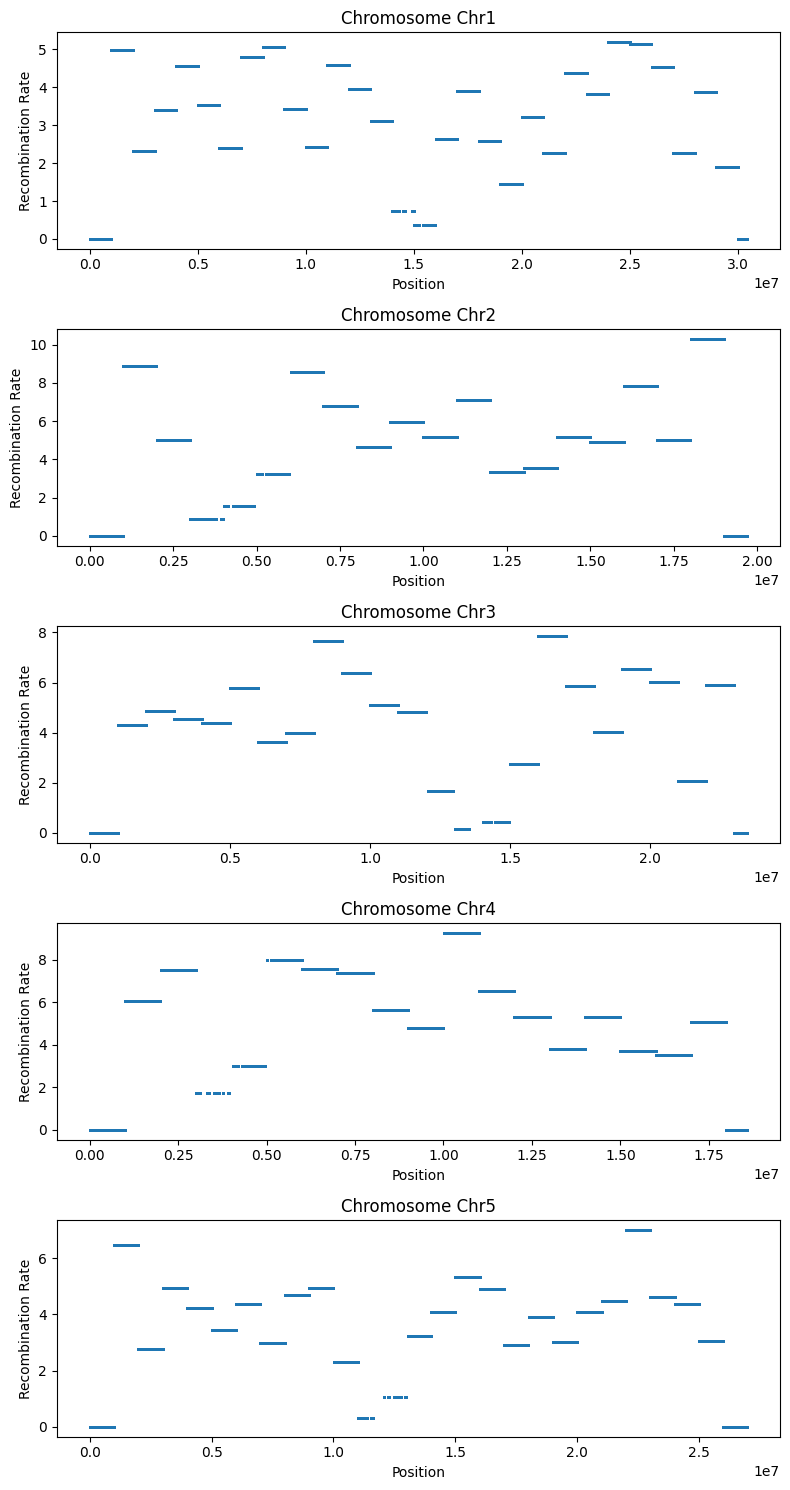

In [ ]:
import matplotlib.pyplot as plt

chromosomes = assigned['Chr'].unique()
n_chr = len(chromosomes)

fig, axes = plt.subplots(n_chr, 1, figsize=(8, 3 * n_chr), sharex=False)

if n_chr == 1:
    axes = [axes]  # Ensure axes is iterable

for ax, chr_name in zip(axes, chromosomes):
    chr_data = assigned[assigned['Chr'] == chr_name]
    ax.scatter(chr_data['pos'], chr_data['recomb_rate'], s=1)
    ax.set_title(f'Chromosome {chr_name}')
    ax.set_xlabel('Position')
    ax.set_ylabel('Recombination Rate')

plt.tight_layout()
plt.show()

In [ ]:
recombination

,Chr,start,end,avg_co
0,Chr1,1,1000000,0.000000
1,Chr1,1000001,2000000,4.982285
2,Chr1,2000001,3000000,2.330887
3,Chr1,3000001,4000000,3.408078
4,Chr1,4000001,5000000,4.568423
...,...,...,...,...
112,Chr5,22000001,23000000,6.994897
113,Chr5,23000001,24000000,4.620219
114,Chr5,24000001,25000000,4.357237
115,Chr5,25000001,26000000,3.037623


In [ ]:
def sum_recomb_between_positions(focal_pos, selected_pos, assigned_chr_df):
    """
    Integrate recombination rate (cM/Mb) over the interval between focal_pos and selected_pos.
    """
    start = min(focal_pos, selected_pos)
    end = max(focal_pos, selected_pos)
    # Get all sites in the interval (excluding focal_pos itself)
    interval_sites = assigned_chr_df[(assigned_chr_df['pos'] >= start) & (assigned_chr_df['pos'] <= end)].sort_values('pos')
    if interval_sites.empty:
        return 0.0
    # Calculate segment lengths (distance between consecutive sites)
    positions = interval_sites['pos'].values
    rates = interval_sites['recomb_rate'].values
    # For N sites, there are N-1 segments; we want to sum rate * segment_length for each segment
    # We'll assume the rate at the left site applies to the segment to the next site
    segment_starts = positions[:-1]
    segment_ends = positions[1:]
    segment_lengths = segment_ends - segment_starts
    segment_rates = rates[:-1]
    segment_Mb = segment_lengths / 1e6
    total_recomb = np.sum(segment_rates * segment_Mb)
    return total_recomb

In [ ]:
def calculate_B_at_focal_site_optimized(focal_pos, focal_chr, assigned, selected_positions,
                                       u_deleterious=1e-9, t_mean=0.001, F=0.9,
                                       max_distance=50e6, max_sites=500):
    """
    Optimized B calculation using assigned recombination rates.
    """
    # 1. Filter assigned for the correct chromosome
    assigned_chr_df = assigned[assigned['Chr'] == focal_chr].copy()
    
    # 2. Spatial filtering - only nearby sites
    distances = np.abs(selected_positions - focal_pos)
    nearby_mask = distances <= max_distance
    nearby_positions = selected_positions[nearby_mask]
    
    if len(nearby_positions) == 0:
        return 1.0
    
    # 3. Downsample if too many sites (keep closest)
    if len(nearby_positions) > max_sites:
        nearby_distances = distances[nearby_mask]
        closest_idx = np.argsort(nearby_distances)[:max_sites]
        nearby_positions = nearby_positions[closest_idx]
    
    # 4. Vectorized calculation of recombination between focal and each selected site
    r_values = np.array([
        sum_recomb_between_positions(focal_pos, pos, assigned_chr_df)
        for pos in nearby_positions
    ])
    
    denominator2 = (1 + (((1-F) * r_values / t_mean)))**2
    contributions = 1 - ((u_deleterious/t_mean) / denominator2)
    
    # Product of all contributions
    B = np.prod(contributions)
    return B

In [ ]:
def get_local_diversity_at_4fold(focal_pos, pi_in_4_fold_sites, window_size=500000):
    
    """Calculate local diversity using ONLY 4-fold sites around a focal site."""
    window_start = focal_pos - window_size / 2
    window_end = focal_pos + window_size / 2

    # Filter the 4-fold data to find sites within the window
    window_sites = pi_in_4_fold_sites[
        (pi_in_4_fold_sites['pos'] >= window_start) &
        (pi_in_4_fold_sites['pos'] <= window_end) &
        (pi_in_4_fold_sites['pi'] > 0)
    ]

    if len(window_sites) == 0:
        # It's possible a window has no 4-fold sites, so we return NaN
        return np.nan

    # Return already calculated pi 
    return window_sites['pi']

In [ ]:
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor

# Note the new 'four_fold_pi_data' argument
def process_site(args):
    focal_pos, focal_chr, t_test, assigned, selected_positions, pi_in_4_fold_sites = args
    B = calculate_B_at_focal_site_optimized(
        focal_pos, focal_chr, assigned, selected_positions, t_mean=t_test
    )
    local_pi = get_local_diversity_at_4fold(focal_pos, pi_in_4_fold_sites, window_size=500000)
    return B, local_pi


def optimize_selection_coeff(assigned, focal_sites, pi_in_4_fold_sites, chrom, n_sites=50, n_jobs=50):
    print("Starting parameter optimization...")

    t_values = [0.005, 0.008, 0.01]
    results = []

    # Get all selected site positions for this chromosome
    selected_positions = assigned[assigned['Chr'] == chrom]['pos'].values

    for t_test in t_values:
        print(f"Testing t_mean = {t_test}")

        if len(focal_sites) > n_sites:
            test_focal_sites = np.random.choice(focal_sites, size=n_sites, replace=False)
        else:
            test_focal_sites = focal_sites

        # Prepare arguments for each focal site
        args = [
            (pos, chrom, t_test, assigned, selected_positions, pi_in_4_fold_sites)
            for pos in test_focal_sites
        ]

        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            results_list = list(executor.map(process_site, args))

        B_values, observed_pi = zip(*results_list)
        B_values = np.array(B_values)
        observed_pi = np.array(observed_pi)

        valid_mask = ~(np.isnan(B_values) | np.isnan(observed_pi) | ~np.isfinite(B_values))

        if np.sum(valid_mask) > 1:
            B_valid = B_values[valid_mask]
            pi_valid = observed_pi[valid_mask]

            correlation = np.corrcoef(B_valid, pi_valid)[0, 1]
            rmse = np.sqrt(np.mean((B_valid - pi_valid) ** 2))
            mean_B = np.mean(B_valid)
            B_range = np.max(B_valid) - np.min(B_valid)

            results.append({
                't_mean': t_test,
                'correlation': correlation,
                'rmse': rmse,
                'mean_B': mean_B,
                'B_range': B_range
            })
        else:
            results.append({
                't_mean': t_test,
                'correlation': np.nan,
                'rmse': np.nan,
                'mean_B': np.nan,
                'B_range': np.nan
            })

    return pd.DataFrame(results)

chromosomes = ['Chr1']

results_by_chr = {}

for chrom in chromosomes:
    print(f"\nOptimizing for {chrom}...")

    # Filter assigned and 4-fold data for the current chromosome
    assigned_chr = assigned[assigned['Chr'] == chrom]
    pi_4fold_chr = pi_in_4_fold_sites[pi_in_4_fold_sites['Chr'] == chrom]

    # Get focal sites within the chromosome range
    min_pos = assigned_chr['pos'].min()
    max_pos = assigned_chr['pos'].max()
    focal_chr = [pos for pos in focal_sites if (pos >= min_pos) and (pos <= max_pos)]

    results_by_chr[chrom] = optimize_selection_coeff(
        assigned_chr,
        focal_chr,
        pi_4fold_chr,
        chrom,
        n_sites=50,
        n_jobs=50
    )

# Combine results into a single DataFrame with chromosome as an index level
all_results = pd.concat(results_by_chr, names=['Chromosome'])
print(all_results)


Optimizing for Chr1...
Starting parameter optimization...
Testing t_mean = 0.005


KeyboardInterrupt: 

In [ ]:
import pandas as pd

best_rows_list = []

for chrom, result_df in results_by_chr.items():
    if result_df.empty or result_df['correlation'].isnull().all():
        print(f"Skipping {chrom} due to empty or invalid results.")
        continue
        
    # This line will correctly find the index of the row where correlation is 0.31 (or the true max)
    best_row_index = result_df['correlation'].idxmax()
    
    best_row = result_df.loc[best_row_index]
    best_row['Chromosome'] = chrom
    best_rows_list.append(best_row)

summary_df = pd.DataFrame(best_rows_list)
summary_df = summary_df[['Chromosome', 't_mean', 'correlation', 'rmse', 'mean_B', 'B_range']]
summary_df = summary_df.sort_values(by='Chromosome').reset_index(drop=True)

print("\n--- Summary of Highest Positive Correlation by Chromosome ---")
print(summary_df)

KeyError: "None of [Index(['Chromosome', 't_mean', 'correlation', 'rmse', 'mean_B', 'B_range'], dtype='object')] are in the [columns]"

In [16]:
# Add this new function to your script
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
import numpy as np

def generate_plot_data(pi_data, recomb_data, focal_sites, four_fold_pi_data, best_t, n_jobs=10):
    """
    Runs the analysis for a single best 't' value to get the data needed for plotting.
    """
    print(f"Generating data for plot with t_mean = {best_t}...")

    # Prepare the arguments for parallel processing
    args = [(pos, best_t, pi_data, recomb_data, four_fold_pi_data) for pos in focal_sites]

    # Run the calculation in parallel
    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        results_list = list(executor.map(process_site, args))

    # Unpack the results
    B_values, observed_pi = zip(*results_list)
    B_values = np.array(B_values)
    observed_pi = np.array(observed_pi)

    # Clean up NaN values which would cause errors in plotting
    valid_mask = ~(np.isnan(B_values) | np.isnan(observed_pi))
    
    B_valid = B_values[valid_mask]
    pi_valid = observed_pi[valid_mask]

    # Return a clean DataFrame
    plot_df = pd.DataFrame({
        'expected_pi': B_valid,
        'observed_pi': pi_valid
    })
    
    return plot_df

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Plot
BEST_T_VALUE = 0.008
TARGET_CHROM = 'Chr1'
focal_chr = [pos for pos in focal_sites if (pos >= min_pos) and (pos <= max_pos)]


plot_dataframe = generate_plot_data_with_positions(
    pi_chr, rec_chr, focal_chr, pi_in_4_fold_sites, best_t=BEST_T_VALUE, n_jobs=30
)

# --- Create the two stacked plots ---
print("Creating plots...")
# Create a figure with 2 subplots, stacked vertically (2 rows, 1 column), sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Expected Pi (B) 
ax1.plot(plot_dataframe['position'], plot_dataframe['expected_pi'], color='blue', alpha=0.8)
ax1.set_title(f'Predicted Diversity (B) along {TARGET_CHROM}', fontsize=16)
ax1.set_ylabel('Expected Diversity (B)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Observed Pi 
ax2.plot(plot_dataframe['position'], plot_dataframe['observed_pi'], color='green', alpha=0.8)
ax2.set_title(f'Observed Diversity (π at 4-fold sites) along {TARGET_CHROM}', fontsize=16)
ax2.set_ylabel('Observed Diversity (π)', fontsize=12)
ax2.set_xlabel('Chromosome Position (bp)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot together
formatter = FuncFormatter(lambda x, pos: f'{x / 1e6:.1f} Mb')
ax2.xaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# Instead of searching dataframe every time

import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor

# ===== ADD THESE OPTIMIZED HELPER FUNCTIONS =====

def create_recomb_lookup(recomb_data):
    """Pre-compute recombination rates for fast lookup"""
    positions = (recomb_data['start'] + recomb_data['end']) / 2
    rates = recomb_data['avg_co'].values
  
    sort_idx = np.argsort(positions)
    positions_sorted = positions.iloc[sort_idx].values
    rates_sorted = rates[sort_idx]
  
    return positions_sorted, rates_sorted

def get_recomb_rate_vectorized(position, recomb_lookup):
    """Fast recombination rate lookup"""
    pos_sorted, rates_sorted = recomb_lookup
    return np.interp(position, pos_sorted, rates_sorted)

def calculate_B_at_focal_site_optimized(focal_pos, selected_positions, recomb_lookup,
                                       u_deleterious=1e-9, t_mean=0.001, F=0.9,
                                       max_distance=50e6, max_sites=5000):
    """Optimized B calculation"""
  
    # 1. Spatial filtering - only nearby sites
    distances = np.abs(selected_positions - focal_pos)
    nearby_mask = distances <= max_distance
    nearby_positions = selected_positions[nearby_mask]
  
    if len(nearby_positions) == 0:
        return 1.0
  
    # 2. Downsample if too many sites (keep closest)
    if len(nearby_positions) > max_sites:
        nearby_distances = distances[nearby_mask]
        closest_idx = np.argsort(nearby_distances)[:max_sites]
        nearby_positions = nearby_positions[closest_idx]
  
    # 3. Vectorized calculation
    rates_cM_Mb = np.array([get_recomb_rate_vectorized(pos, recomb_lookup) 
                           for pos in nearby_positions])
  
    distances_bp = np.abs(nearby_positions - focal_pos)
    distances_Mb = distances_bp / 1e6
    r_values = rates_cM_Mb * distances_Mb
  
    # Calculate contributions vectorized
    #denominator = (1 + (((1-F) * r_values * (1-t_mean)) / t_mean))**2
    denominator2 = (1 + (((1-F) * r_values  / t_mean)))**2
    contributions = 1 - ((u_deleterious/t_mean) / denominator2)
  
    # Product of all contributions
    B = np.prod(contributions)
    return B

def create_diversity_lookup(four_fold_data):
    """Pre-compute diversity lookup"""
    sorted_data = four_fold_data.sort_values('pos')
    positions = sorted_data['pos'].values
    pi_values = sorted_data['pi'].values
    return positions, pi_values

def get_local_diversity_optimized(focal_pos, diversity_lookup, window_size=500000):
    """Optimized local diversity calculation"""
    positions, pi_values = diversity_lookup
    half_window = window_size / 2
  
    # Binary search for window boundaries
    start_idx = np.searchsorted(positions, focal_pos - half_window, side='left')
    end_idx = np.searchsorted(positions, focal_pos + half_window, side='right')
  
    window_pi = pi_values[start_idx:end_idx]
    window_pi = window_pi[window_pi > 0]  # Remove zeros
  
    if len(window_pi) > 0:
        return np.mean(window_pi)
    else:
        return np.nan

# ===== MODIFY YOUR EXISTING FUNCTIONS =====

def process_site_optimized(args):
    """Optimized process_site function"""
    focal_pos, t_test, selected_positions, recomb_lookup, diversity_lookup = args
  
    # Calculate B using optimized function
    B = calculate_B_at_focal_site_optimized(
        focal_pos, selected_positions, recomb_lookup, 
        u_deleterious=1e-9, t_mean=t_test, F=0.9
    )
  
    # Calculate local diversity using optimized function
    local_pi = get_local_diversity_optimized(focal_pos, diversity_lookup)
  
    return B, local_pi

def optimize_selection_coeff_optimized(pi_data, recomb_data, focal_sites, four_fold_pi_data, 
                                     n_sites=1000, n_jobs=50):
    """Optimized optimization function"""
    print("Starting parameter optimization...")
  
    # PRE-COMPUTE lookups (do this once per chromosome)
    print("Creating lookup tables...")
    recomb_lookup = create_recomb_lookup(recomb_data)
    diversity_lookup = create_diversity_lookup(four_fold_pi_data)
  
    # Get selected site positions as numpy array
    selected_sites = pi_data[pi_data['is_selected'] == True]
    selected_positions = selected_sites['pos'].values
  
    t_values =[0.001, 0.005, 0.008, 0.01, 0.02, 0.03]
    results = []
  
    for t_test in t_values:
        print(f"Testing t_mean = {t_test}")
      
        # Sample focal sites
        if len(focal_sites) > n_sites:
            test_focal_sites = np.random.choice(focal_sites, size=n_sites, replace=False)
        else:
            test_focal_sites = focal_sites
      
        # Prepare arguments for parallel processing
        args = [(pos, t_test, selected_positions, recomb_lookup, diversity_lookup) 
                for pos in test_focal_sites]
      
        # Parallel processing
        with ProcessPoolExecutor(max_workers=n_jobs) as executor:
            results_list = list(executor.map(process_site_optimized, args))
      
        # Process results
        B_values, observed_pi = zip(*results_list)
        B_values = np.array(B_values)
        observed_pi = np.array(observed_pi)
      
        valid_mask = ~(np.isnan(B_values) | np.isnan(observed_pi) | ~np.isfinite(B_values))
      
        if np.sum(valid_mask) > 1:
            B_valid = B_values[valid_mask]
            pi_valid = observed_pi[valid_mask]
          
            correlation = np.corrcoef(B_valid, pi_valid)[0, 1]
            rmse = np.sqrt(np.mean((B_valid - pi_valid) ** 2))
            mean_B = np.mean(B_valid)
            B_range = np.max(B_valid) - np.min(B_valid)
          
            results.append({
                't_mean': t_test,
                'correlation': correlation,
                'rmse': rmse,
                'mean_B': mean_B,
                'B_range': B_range
            })
        else:
            results.append({
                't_mean': t_test,
                'correlation': np.nan,
                'rmse': np.nan,
                'mean_B': np.nan,
                'B_range': np.nan
            })
  
    return pd.DataFrame(results)

# ===== YOUR MAIN LOOP (UPDATED) =====

chromosomes = ['Chr1']
results_by_chr = {}

for chrom in chromosomes:
    print(f"\\nProcessing {chrom}...")
  
    # Filter data for chromosome
    pi_chr = pi_nonzero[pi_nonzero['Chr'] == chrom]
    rec_chr = recombination[recombination['Chr'] == chrom]
    pi_4fold_chr = pi_in_4_fold_sites[pi_in_4_fold_sites['Chr'] == chrom]
  
    # Get focal sites for chromosome
    min_pos = pi_chr['pos'].min()
    max_pos = pi_chr['pos'].max()
    focal_chr = [pos for pos in focal_sites if (pos >= min_pos) and (pos <= max_pos)]
  
    print(f"Chromosome {chrom}: {len(focal_chr)} focal sites, {len(pi_chr)} total sites")
  
    # Run optimized optimization
    results_by_chr[chrom] = optimize_selection_coeff_optimized(
        pi_chr, 
        rec_chr, 
        focal_chr, 
        pi_4fold_chr,
        n_sites=1000,
        n_jobs=50
    )

In [ ]:
results_by_chr

In [ ]:
results_by_chr